# 0.0 Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import inflection
import xgboost as xgb
import catboost as cat

from sklearn import metrics as mt
from matplotlib import pyplot as plt
from IPython.display    import HTML
from ydata_profiling import ProfileReport
from sklearn.model_selection import train_test_split, cross_validate, TunedThresholdClassifierCV, StratifiedKFold
from sklearn            import ensemble             as en
from sklearn            import linear_model         as lm
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder

d:\Comunidade DS\Portifólio de Projetos\repos\ds_fraud\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0.1 Helper Functions

In [2]:
def jupyter_settings():
    %matplotlib inline

    plt.style.use( 'bmh' )
    plt.rcParams['figure.figsize'] = [25, 12]
    plt.rcParams['font.size'] = 24

    display( HTML( '<style>.container { width:100% !important; }</style>') )
    pd.options.display.max_columns = None
    pd.options.display.max_rows = None
    pd.set_option( 'display.expand_frame_repr', False )

    sns.set()

jupyter_settings()

def drop_columns(X, cols=None):
    if cols is None:
        return X
    return X.drop(columns=cols)

## 0.2 Loading Data

In [3]:
df_raw = pd.read_csv('../data/raw/PS_20174392719_1491204439457_log.csv', low_memory=False)

In [4]:
df_raw.sample()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2931919,229,PAYMENT,23307.45,C1175258167,102.0,0.0,M494392885,0.0,0.0,0,0


# 1.0 Descrição dos dados

In [5]:
df1 = df_raw.copy()

## 1.1 Rename Columns

In [6]:
df1.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [7]:
cols_old = ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud']

snakecase = lambda x: inflection.underscore( x )

cols_new = list (map (snakecase, cols_old))


df1.columns = cols_new

## 1.2 Data Dimensions

In [8]:
print('Number of Rows: {}'.format(df1.shape[0]))
print('Number of Columns: {}'.format(df1.shape[1]))

Number of Rows: 6362620
Number of Columns: 11


## 1.3 Data Types

In [9]:
df1.dtypes

step                  int64
type                 object
amount              float64
name_orig            object
oldbalance_org      float64
newbalance_orig     float64
name_dest            object
oldbalance_dest     float64
newbalance_dest     float64
is_fraud              int64
is_flagged_fraud      int64
dtype: object

## 1.4 Check NA

In [10]:
df1.isna().sum()

step                0
type                0
amount              0
name_orig           0
oldbalance_org      0
newbalance_orig     0
name_dest           0
oldbalance_dest     0
newbalance_dest     0
is_fraud            0
is_flagged_fraud    0
dtype: int64

## 1.5 Descriptive Statistical

In [11]:
# profile = ProfileReport(df1)
# profile.to_file('../reports/raw_data_report.html')

In [12]:
num_attributes = df1.select_dtypes( include=['int64', 'float64'])
cat_attributes = df1.select_dtypes( exclude=['int64', 'float64', 'datetime64[ns]'])

In [13]:
cat_attributes.sample(5)

,type,name_orig,name_dest
4831678,CASH_IN,C357833305,C1364465732
927090,CASH_OUT,C457604682,C630635113
5791272,TRANSFER,C911252477,C537666752
3156843,PAYMENT,C857049593,M780878574
4791944,CASH_OUT,C482299819,C40218549


### 1.5.1 Numerical Attributes

In [14]:
# Central Tendency - mean, median

ct1 = pd.DataFrame (num_attributes.apply(np.mean)).T
ct2 = pd.DataFrame (num_attributes.apply(np.median)).T

# Dispersion - std, min, max, range, skew, kurtosis

d1 = pd.DataFrame (num_attributes.apply(np.std)).T
d2 = pd.DataFrame (num_attributes.apply(min)).T
d3 = pd.DataFrame (num_attributes.apply(max)).T
d4= pd.DataFrame (num_attributes.apply(lambda x: x.max() - x.min())).T
d5= pd.DataFrame (num_attributes.apply(lambda x: x.skew())).T
d6= pd.DataFrame (num_attributes.apply(lambda x: x.kurtosis())).T

# concatenate
m = pd.concat([d2 ,d3 ,d4 , ct1 ,ct2 , d1 , d5 , d6]).T.reset_index()
m. columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis' ]

m

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,step,1.0,7.430000e+02,7.420000e+02,2.433972e+02,239.000,1.423320e+02,0.375177,0.329071
1,amount,0.0,9.244552e+07,9.244552e+07,1.798619e+05,74871.940,6.038582e+05,30.993949,1797.956705
2,oldbalance_org,0.0,5.958504e+07,5.958504e+07,8.338831e+05,14208.000,2.888242e+06,5.249136,32.964879
3,newbalance_orig,0.0,4.958504e+07,4.958504e+07,8.551137e+05,0.000,2.924048e+06,5.176884,32.066985
4,oldbalance_dest,0.0,3.560159e+08,3.560159e+08,1.100702e+06,132705.665,3.399180e+06,19.921758,948.674125
5,newbalance_dest,0.0,3.561793e+08,3.561793e+08,1.224996e+06,214661.440,3.674129e+06,19.352302,862.156508
6,is_fraud,0.0,1.000000e+00,1.000000e+00,1.290820e-03,0.000,3.590479e-02,27.779538,769.702982
7,is_flagged_fraud,0.0,1.000000e+00,1.000000e+00,2.514687e-06,0.000,1.585775e-03,630.603629,397659.062500


### 1.5.2 Categorical Attributes

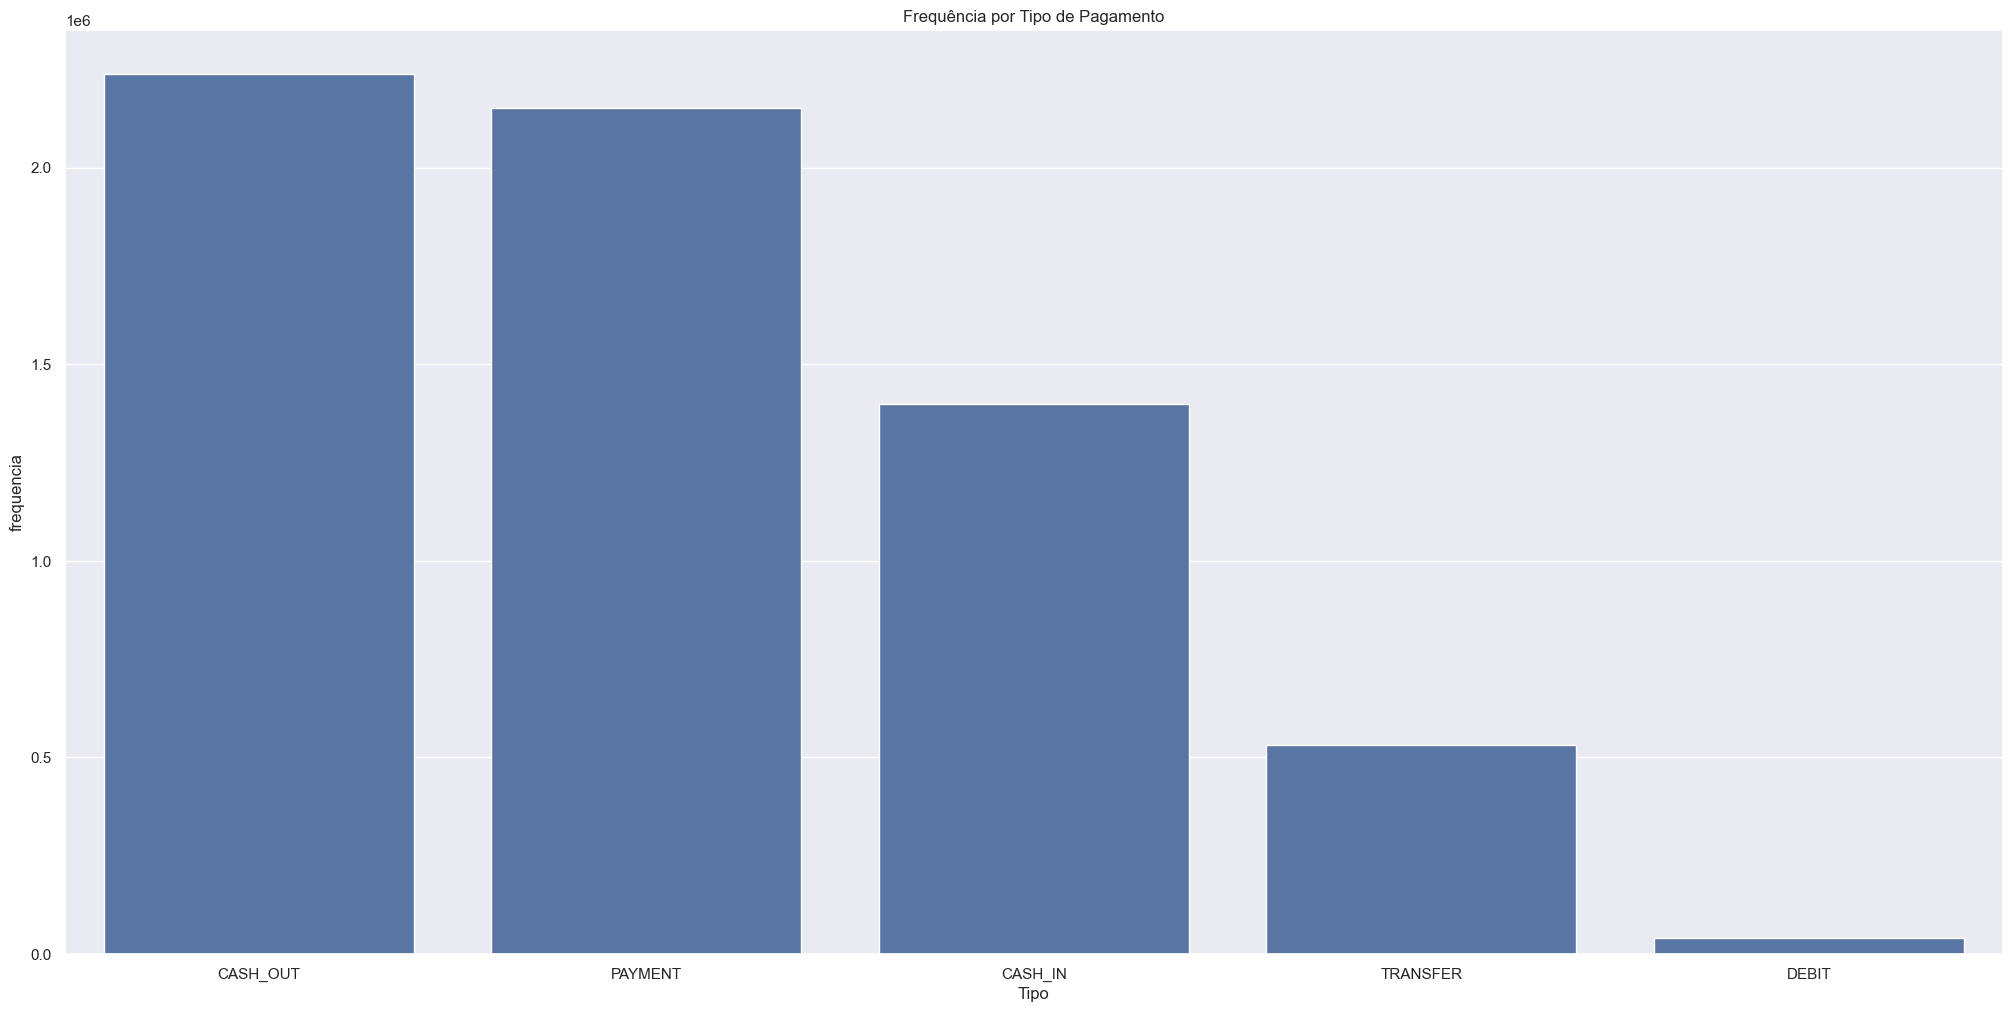

In [15]:
contagem = df1['type'].value_counts().reset_index()
contagem.columns = ['Tipo', 'frequencia']

# Gráfico de barras
sns.barplot(data=contagem, x='Tipo', y='frequencia')
plt.title('Frequência por Tipo de Pagamento')
plt.show()

# 2.0 Feature Engineering

In [16]:
df2 = df1.copy()

In [17]:
def period(h):
    if 5 <= h < 12:
        return 'Morning'
    elif 12 <= h < 18:
        return 'Afternoon'
    elif 18 <= h < 24:
        return 'Evening'
    else:
        return 'Night'

In [18]:
# dia

df2['day'] = (df2['step'] // 24) + 1

# hora 

df2['hora'] = df2['step'] % 24

# periodo do dia

df2['period_of_day'] = df2['hora'].apply(period)

In [19]:
df_aux_fraud1 = df2[(df2['is_fraud'] == 1) & (df2['period_of_day'] == 'Morning')]
df_aux_fraud2 = df2[(df2['is_fraud'] == 1) & (df2['period_of_day'] == 'Afternoon')]
df_aux_fraud3 = df2[(df2['is_fraud'] == 1) & (df2['period_of_day'] == 'Evening')]
df_aux_fraud4 = df2[(df2['is_fraud'] == 1) & (df2['period_of_day'] == 'Night')]

In [20]:
print(f"Fraudes no periodo da manha: {df_aux_fraud1.shape[0]}")
print(f"Fraudes no periodo da tarde: {df_aux_fraud2.shape[0]}")
print(f"Fraudes no periodo da noite: {df_aux_fraud3.shape[0]}")
print(f"Fraudes no periodo da madrugada: {df_aux_fraud4.shape[0]}")

Fraudes no periodo da manha: 2460
Fraudes no periodo da tarde: 2077
Fraudes no periodo da noite: 2046
Fraudes no periodo da madrugada: 1630


# 3.0 Filtragem de Variáveis

In [21]:
df3 = df2.copy()

In [22]:
df3.sample(5)

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
218631,13,PAYMENT,7153.78,C399858262,2276719.03,2269565.24,M572195961,0.00,0.00,0,0,1,13,Afternoon
2411373,202,CASH_OUT,295336.39,C1453715600,44327.00,0.00,C1240347914,2069471.99,2364808.37,0,0,9,10,Morning
4337353,308,CASH_IN,120013.36,C670419952,303500.36,423513.72,C918931014,610905.74,490892.38,0,0,13,20,Evening
270339,15,CASH_OUT,205197.82,C850169127,3993.00,0.00,C2094161748,9958.00,181907.78,0,0,1,15,Afternoon
5685301,397,PAYMENT,35305.52,C962049534,0.00,0.00,M1719149968,0.00,0.00,0,0,17,13,Afternoon


In [23]:
# Não existe nenhum cliente de origem do tipo Merchant
df_aux2 = df3[df3['name_dest'].str.contains(r'^M', na=False)]

In [24]:
# Não existe nenhuma transição de Merchant classificada como fraude
df_aux2[df_aux2['is_fraud'] == 1].shape

(0, 14)

In [25]:
df_aux = df3[df3['amount'] > 9000000]

In [26]:
df_aux.shape

(6335, 14)

In [27]:
df3_filtered = df3[(~df3['name_dest'].str.contains(r'^M', na=False)) & (df3['amount'] <= 8999999) ]

In [28]:
df3_filtered.shape

(4204790, 14)

In [29]:
num_attributes = df3_filtered.select_dtypes( include=['int64', 'float64'])
cat_attributes = df3_filtered.select_dtypes( exclude=['int64', 'float64', 'datetime64[ns]'])

# 4.0 Análise Exploratória de Dados

In [30]:
df4 = df3_filtered.copy()

## 4.1 Análise Univariada

### 4.1.1 Response Variable

In [31]:
df_valid = df4[df4['is_fraud'] == 0]
df_fraud = df4[df4['is_fraud'] == 1]
df_flagged_fraud = df4[df4['is_flagged_fraud'] == 1] 


print(f'Quantidade de transações válidas: {df_valid.shape[0]}')
print(f'Quantidade de transações fraudulentas: {df_fraud.shape[0]}')
print(f'Quantidade de transações com flag de fraudulentas: {df_flagged_fraud.shape[0]}')

Quantidade de transações válidas: 4196921
Quantidade de transações fraudulentas: 7869
Quantidade de transações com flag de fraudulentas: 12


In [32]:
df_fraud['amount'].max()

np.float64(8994286.69)

In [33]:
df_fraud.sample(10)

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
3363957,254,CASH_OUT,653949.74,C1985193615,653949.74,0.0,C967226405,1404475.93,2058425.67,1,0,11,14,Afternoon
6074059,515,TRANSFER,290211.26,C276602564,290211.26,0.0,C58143708,0.00,0.00,1,0,22,11,Morning
5506814,380,TRANSFER,3070709.95,C739766096,3070709.95,0.0,C2100602462,0.00,0.00,1,0,16,20,Evening
1059645,111,CASH_OUT,574709.63,C132473843,574709.63,0.0,C101909578,0.00,574709.63,1,0,5,15,Afternoon
6131928,543,TRANSFER,57204.07,C2080854887,57204.07,0.0,C2001477258,0.00,0.00,1,0,23,15,Afternoon
6100665,523,CASH_OUT,921894.19,C1069707218,921894.19,0.0,C1691436572,523285.83,1445180.02,1,0,22,19,Evening
1030523,70,TRANSFER,266766.78,C2105673103,266766.78,0.0,C98079296,0.00,0.00,1,0,3,22,Evening
3929212,285,TRANSFER,411566.70,C24910757,411566.70,0.0,C1647415714,0.00,0.00,1,0,12,21,Evening
1030762,91,CASH_OUT,921668.95,C1505563519,921668.95,0.0,C863042157,96395.54,1018064.50,1,0,4,19,Evening
6186783,568,TRANSFER,2895954.99,C1706066378,2895954.99,0.0,C1293124691,0.00,0.00,1,0,24,16,Afternoon


In [34]:
# Para ter uma flag de fraud é quando a transação é maior que 200k
df_flagged_fraud.sample(10)

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
6266413,617,TRANSFER,2542664.27,C786455622,2542664.27,2542664.27,C661958277,0.0,0.0,1,1,26,17,Afternoon
6205439,586,TRANSFER,353874.22,C1684585475,353874.22,353874.22,C1770418982,0.0,0.0,1,1,25,10,Morning
6296014,671,TRANSFER,3441041.46,C917414431,3441041.46,3441041.46,C1082139865,0.0,0.0,1,1,28,23,Evening
2736446,212,TRANSFER,4953893.08,C728984460,4953893.08,4953893.08,C639921569,0.0,0.0,1,1,9,20,Evening
3247297,250,TRANSFER,1343002.08,C1100582606,1343002.08,1343002.08,C1147517658,0.0,0.0,1,1,11,10,Morning
6281484,646,TRANSFER,399045.08,C724693370,10399045.08,10399045.08,C1909486199,0.0,0.0,1,1,27,22,Evening
6351225,702,TRANSFER,3171085.59,C1892216157,3171085.59,3171085.59,C1308068787,0.0,0.0,1,1,30,6,Morning
3760288,279,TRANSFER,536624.41,C1035541766,536624.41,536624.41,C1100697970,0.0,0.0,1,1,12,15,Afternoon
6362584,741,TRANSFER,5674547.89,C992223106,5674547.89,5674547.89,C1366804249,0.0,0.0,1,1,31,21,Evening
6362462,730,TRANSFER,7316255.05,C1869569059,17316255.05,17316255.05,C1861208726,0.0,0.0,1,1,31,10,Morning


In [35]:
df_test = df4[df4['amount'] >= 200000]

In [36]:
df_test.sample(5)

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
1228584,133,CASH_IN,351956.31,C856188093,8580144.49,8932100.8,C575611536,538773.16,186816.85,0,0,6,13,Afternoon
4785998,345,CASH_OUT,470910.29,C1331785877,0.00,0.0,C751855239,1092602.76,1563513.04,0,0,15,9,Morning
1127854,131,CASH_OUT,449121.16,C266253312,0.00,0.0,C1538100296,646735.27,1095856.42,0,0,6,11,Morning
6000888,426,TRANSFER,406660.24,C510193714,0.00,0.0,C1529397807,1773785.72,2180445.96,0,0,18,18,Evening
5267831,372,TRANSFER,1609593.36,C899665453,0.00,0.0,C30136507,2071023.39,3680616.75,0,0,16,12,Afternoon


### 4.1.2 Numerical Attributes

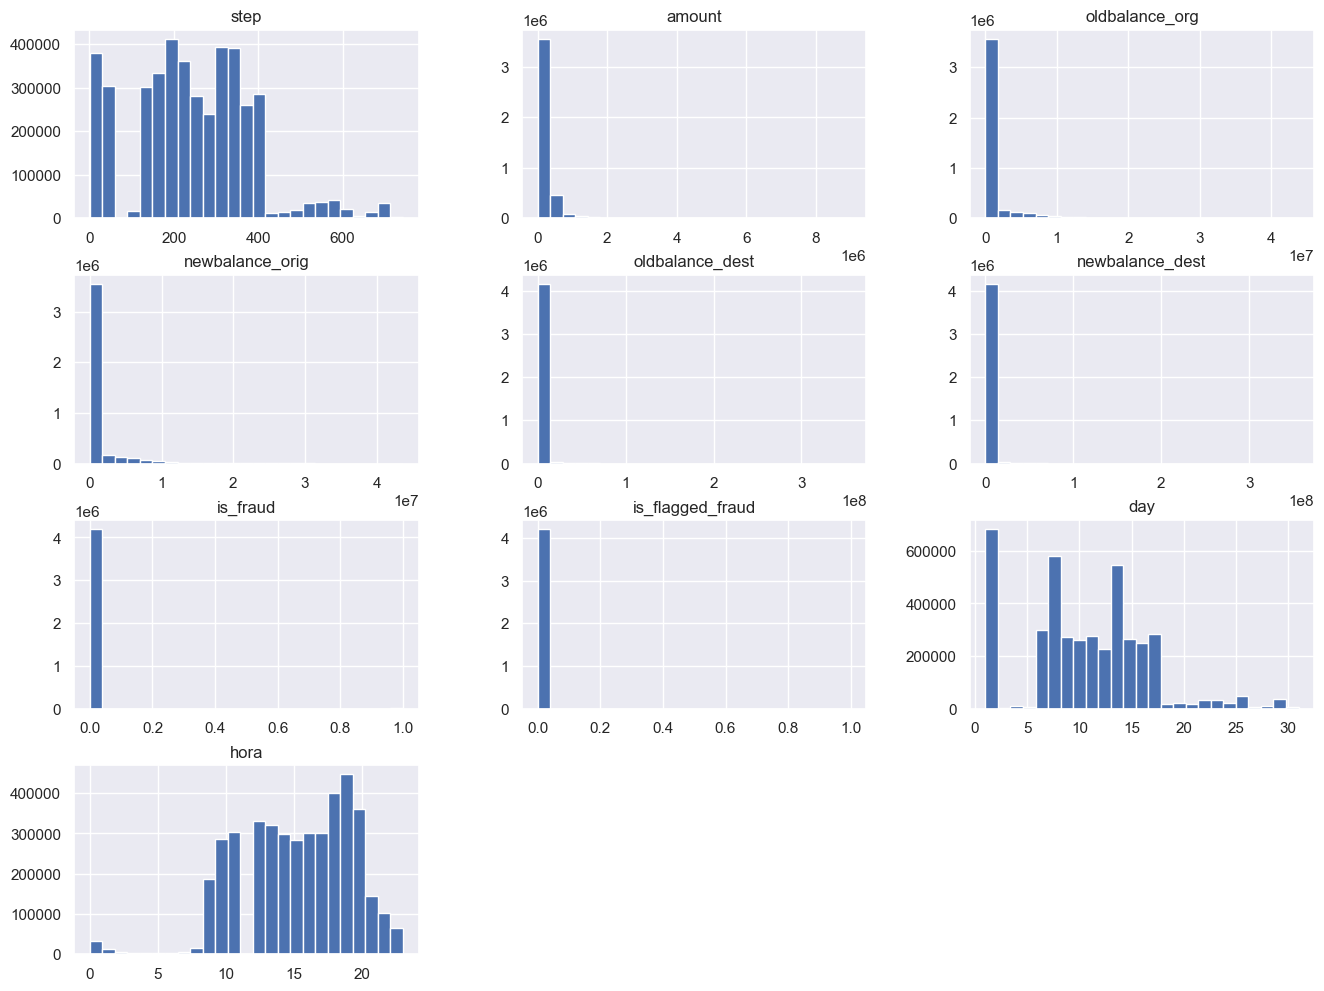

In [37]:
num_attributes.hist(bins= 25, figsize=(16,12));

### 4.1.2 Categorical Variables

<Axes: xlabel='count', ylabel='type'>

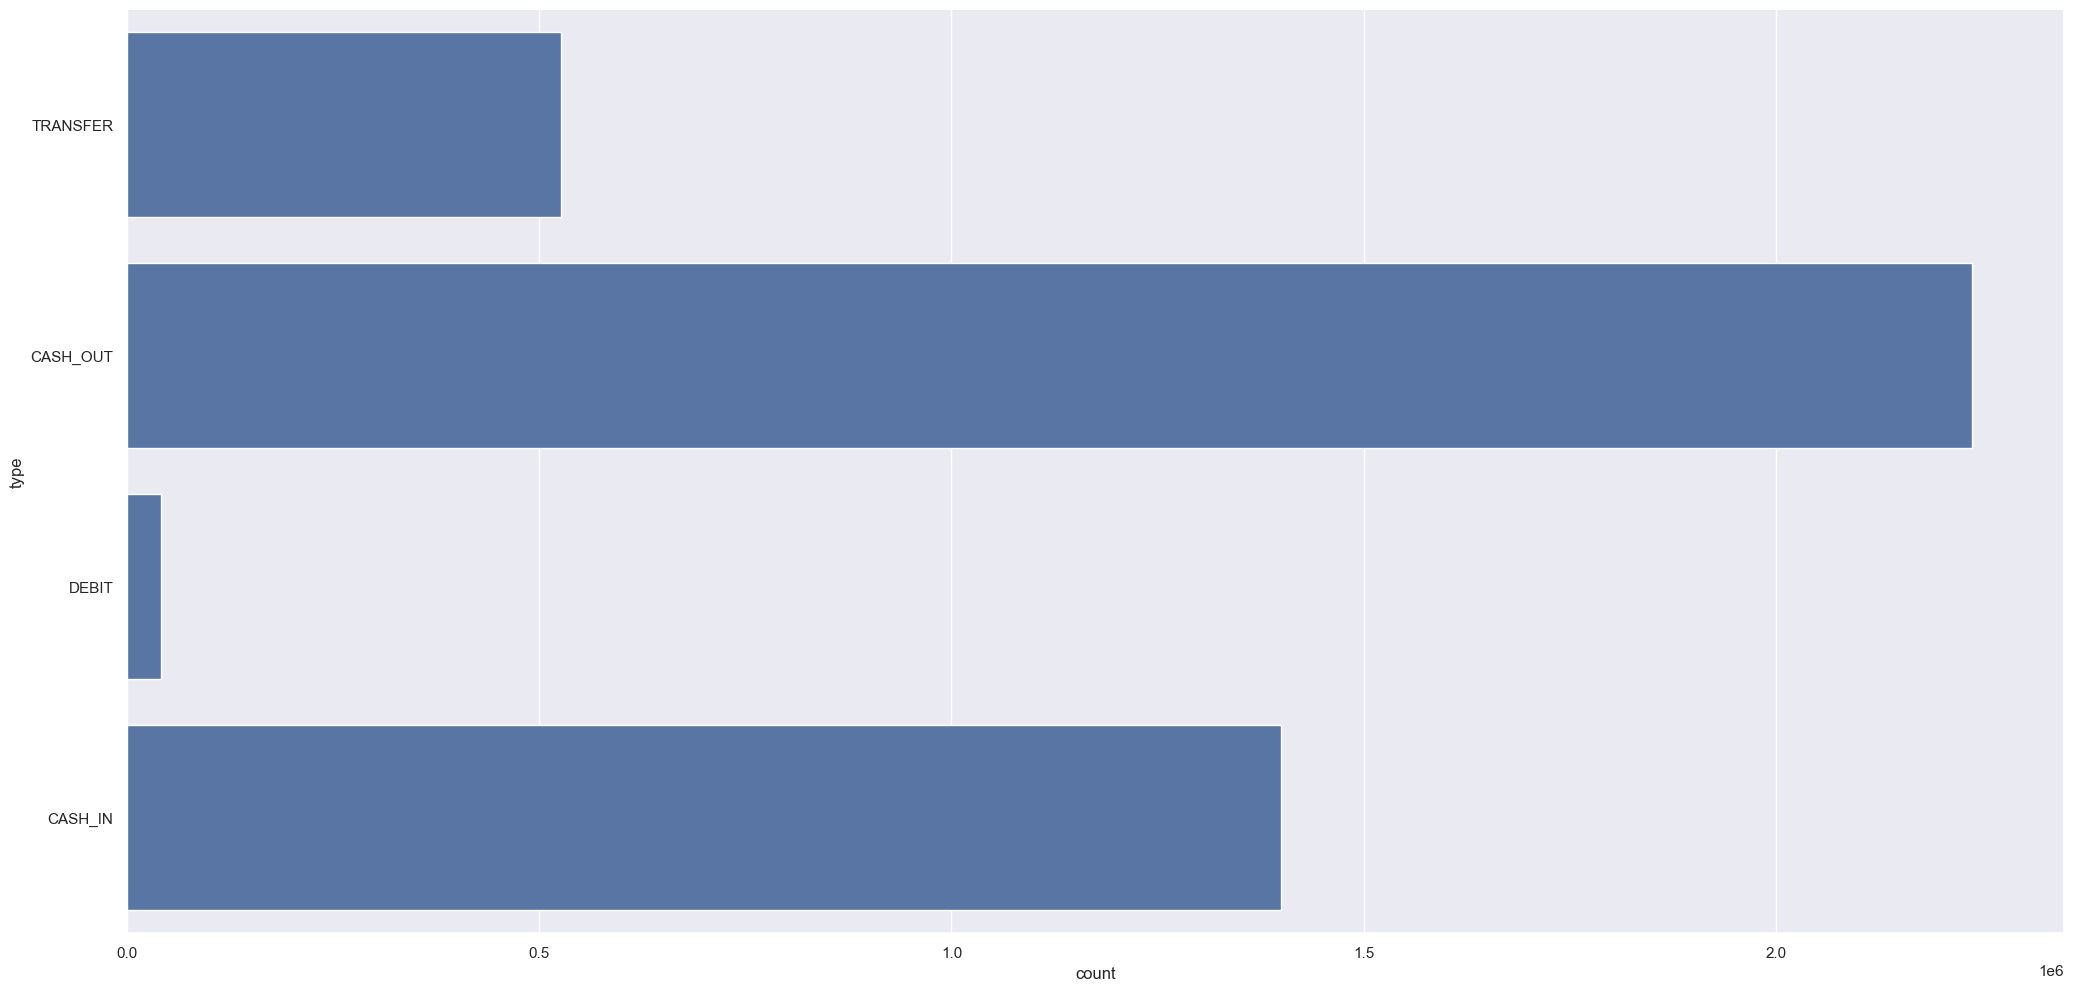

In [38]:
sns.countplot (df4['type'])

## 4.2 Analise Bivariada

In [39]:
df4.columns

Index(['step', 'type', 'amount', 'name_orig', 'oldbalance_org',
       'newbalance_orig', 'name_dest', 'oldbalance_dest', 'newbalance_dest',
       'is_fraud', 'is_flagged_fraud', 'day', 'hora', 'period_of_day'],
      dtype='object')

<Axes: xlabel='type', ylabel='is_fraud'>

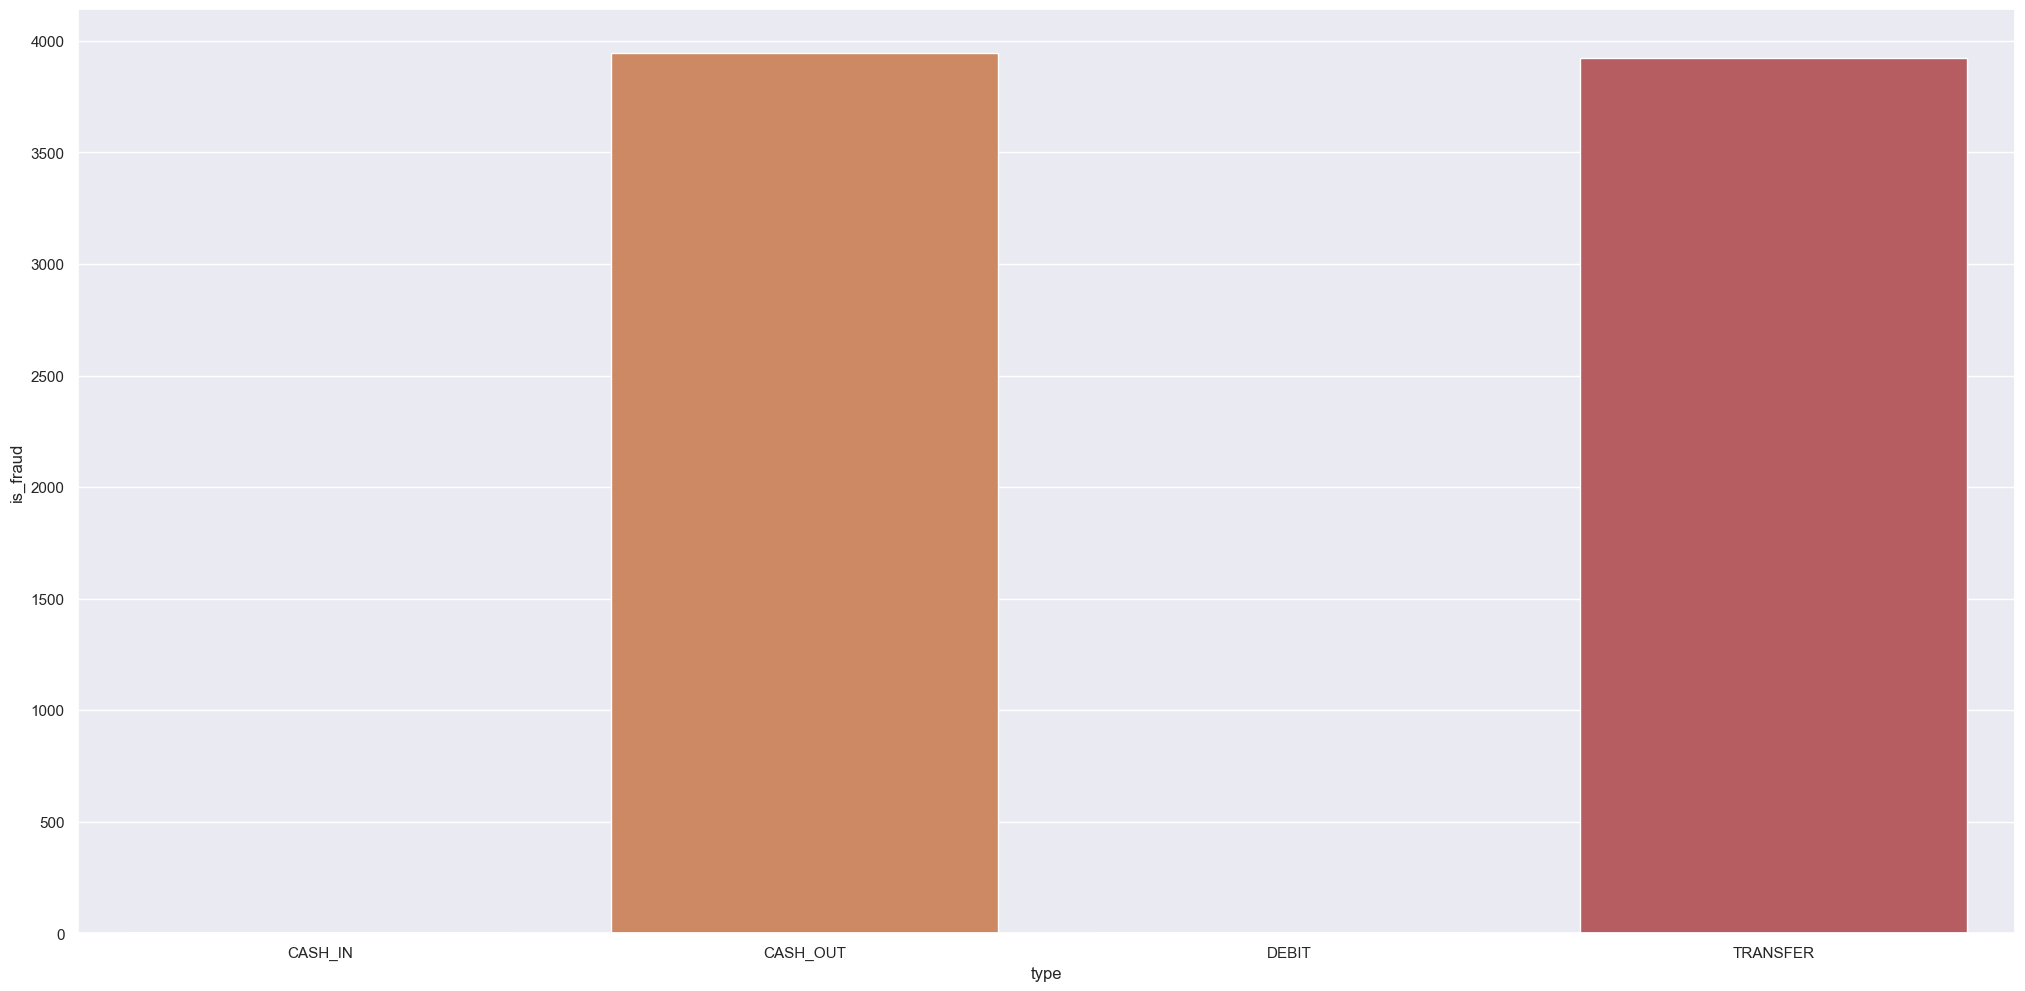

In [40]:
# Tipos de Transações que mais são fraudes

aux1 = df4[['type', 'is_fraud']].groupby('type').sum().reset_index()

sns.barplot( x='type', y='is_fraud', data=aux1, hue='type')

<Axes: xlabel='period_of_day', ylabel='is_fraud'>

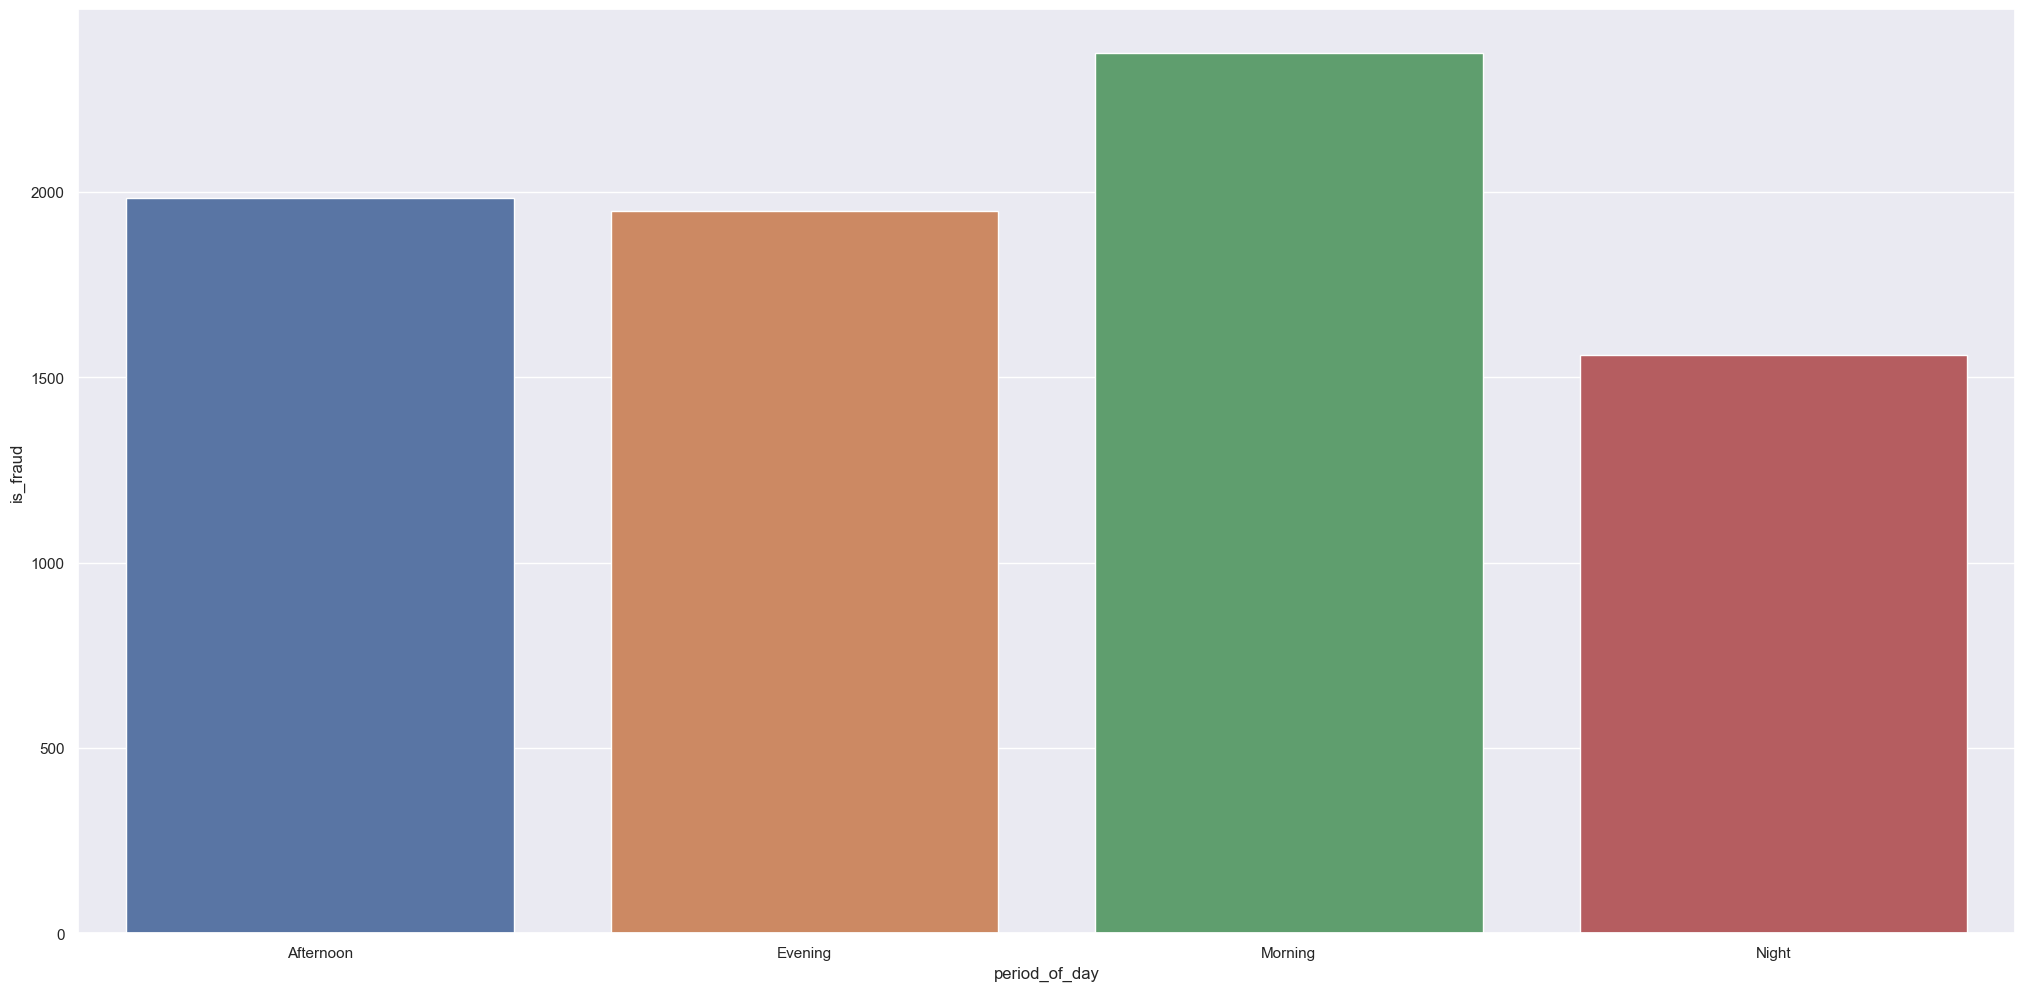

In [41]:
# Periodo do dia que mais ocorrem fraudes

aux1 = df4[['period_of_day', 'is_fraud']].groupby('period_of_day').sum().reset_index()

sns.barplot( x='period_of_day', y='is_fraud', data=aux1, hue='period_of_day')

In [42]:
df4.head()

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.00,1,0,1,1,Night
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.00,1,0,1,1,Night
9,1,DEBIT,5337.77,C712410124,41720.0,36382.23,C195600860,41898.0,40348.79,0,0,1,1,Night
10,1,DEBIT,9644.94,C1900366749,4465.0,0.00,C997608398,10845.0,157982.12,0,0,1,1,Night
15,1,CASH_OUT,229133.94,C905080434,15325.0,0.00,C476402209,5083.0,51513.44,0,0,1,1,Night


In [43]:
# Quantidade de transações fraudulentas no qual o total enviado é igual ao valor total da conta
aux2 = df4[df4['amount'] == df4['oldbalance_org']]

aux2.head()

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
2,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1,0,1,1,Night
3,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1,0,1,1,Night
251,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1,0,1,1,Night
252,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1,0,1,1,Night
680,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1,0,1,1,Night


In [44]:
# Quantidade de transações válidas: 4196921
# Quantidade de transações fraudulentas: 7869
# Quantidade de transações com flag de fraudulentas: 12

In [45]:
aux2.shape

(7836, 14)

In [46]:
# As transações que são fraudes, geralmente são aquelas transações que "limpam" o valor da conta do cliente.

In [47]:
# Não existe clientes que fizeram mais de uma transação fraudulenta
fraude_por_cliente = df4[df4['is_fraud'] == 1].groupby('name_orig').size().reset_index(name='fraude_total')

In [48]:
df_fraud_aux = df4.merge(fraude_por_cliente, on='name_orig', how='left')

In [49]:
df_fraud_aux['fraude_total'] = df_fraud_aux['fraude_total'].fillna(0)
df_fraud_aux.head()

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day,fraude_total
0,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.00,1,0,1,1,Night,1.0
1,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.00,1,0,1,1,Night,1.0
2,1,DEBIT,5337.77,C712410124,41720.0,36382.23,C195600860,41898.0,40348.79,0,0,1,1,Night,0.0
3,1,DEBIT,9644.94,C1900366749,4465.0,0.00,C997608398,10845.0,157982.12,0,0,1,1,Night,0.0
4,1,CASH_OUT,229133.94,C905080434,15325.0,0.00,C476402209,5083.0,51513.44,0,0,1,1,Night,0.0


<Axes: xlabel='fraude_total', ylabel='count'>

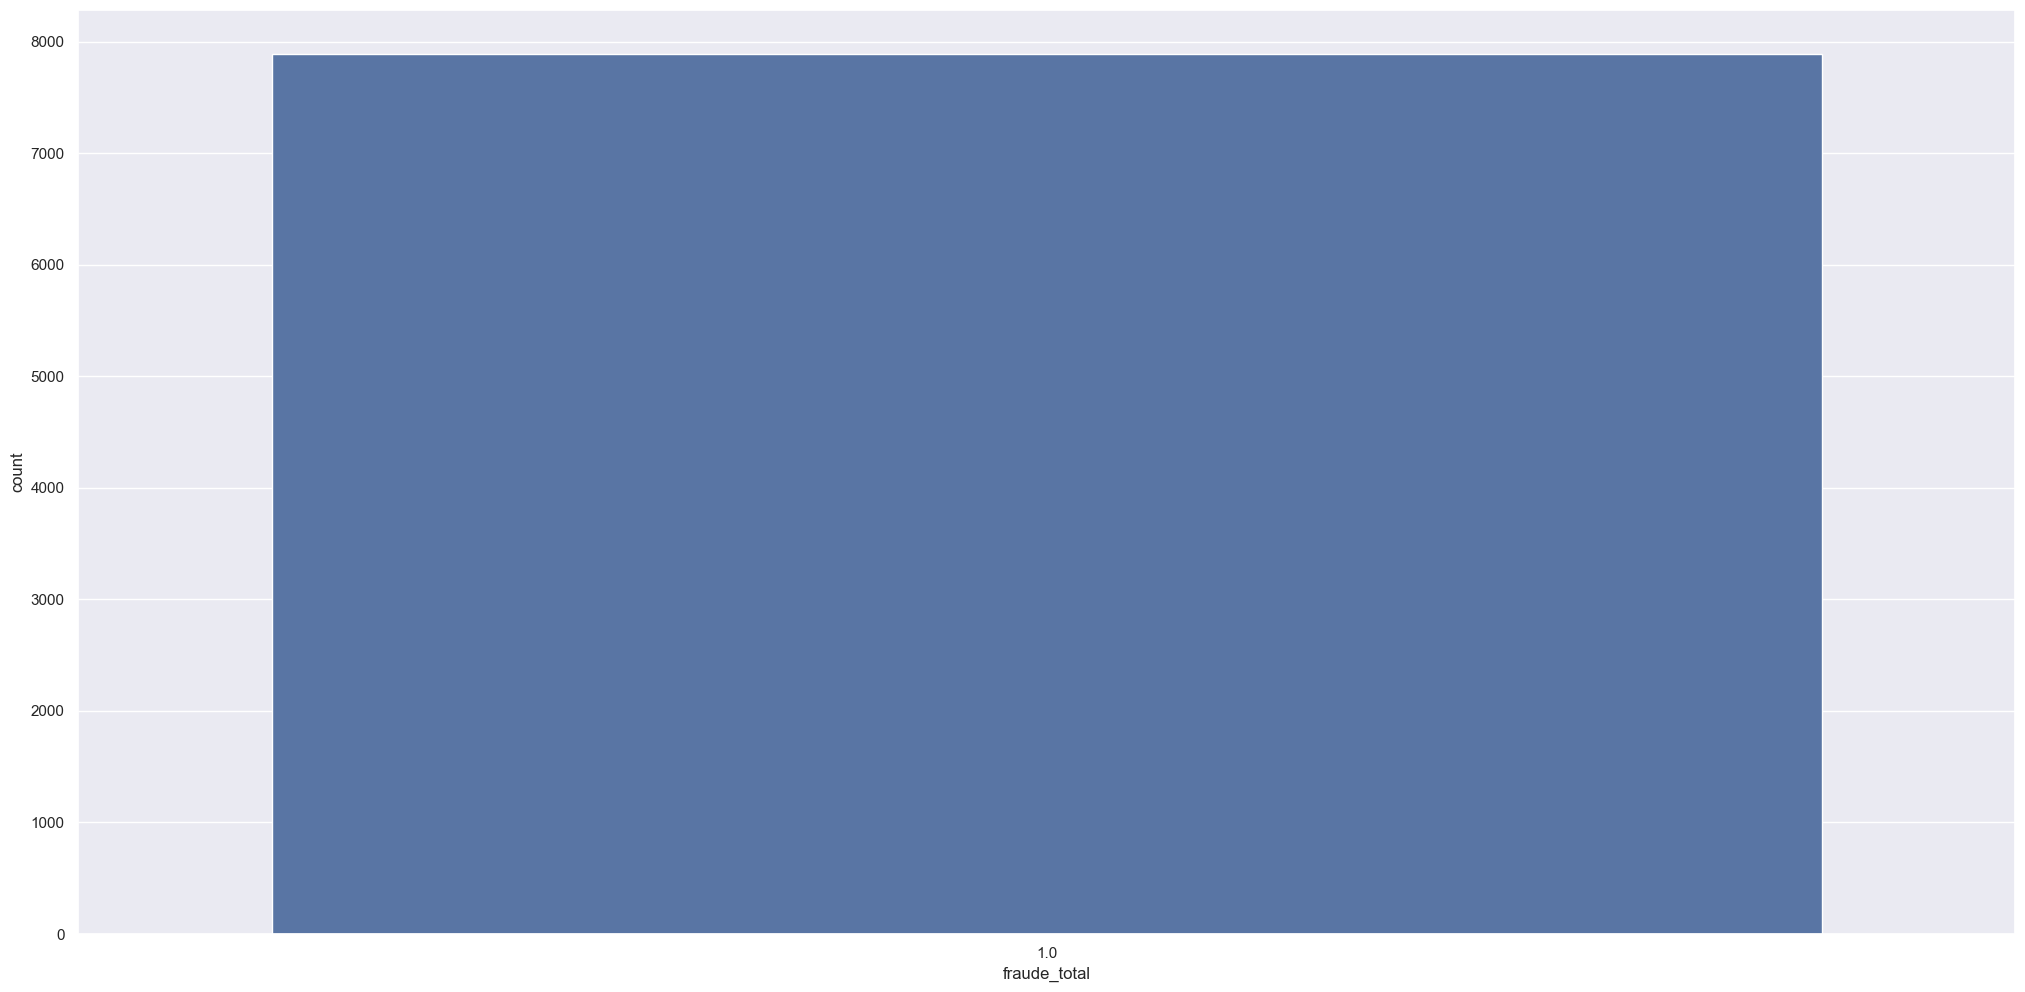

In [50]:

sns.countplot(data=df_fraud_aux[df_fraud_aux['fraude_total'] > 0], x='fraude_total')

## 4.3 Análise Multivariada

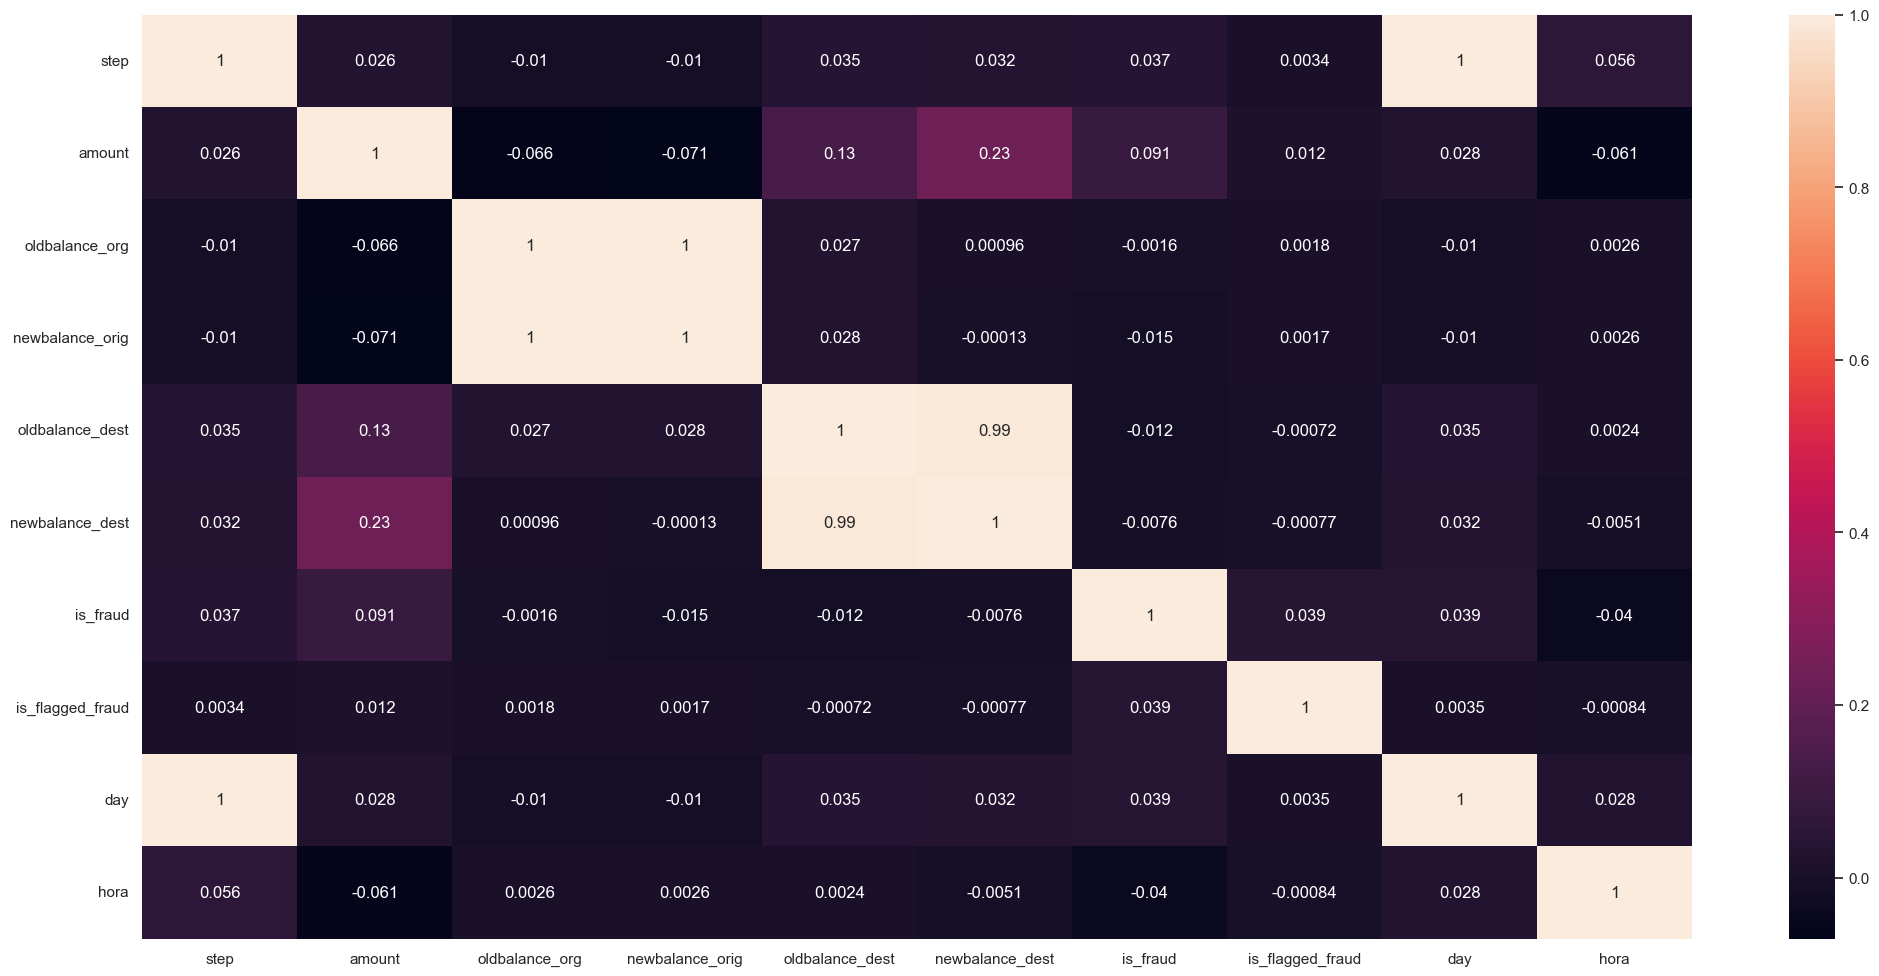

In [51]:
correlation = num_attributes.corr(method='pearson')
sns.heatmap(correlation, annot=True);

# 5.0 Data Preparation

In [52]:
df5 = df4.copy()

In [53]:
X = df5.copy()
y = df5['is_fraud']
X = X.drop('is_fraud', axis=1)

## 5.2 Train Test Validation Split

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X , y , test_size=0.2, random_state=42, stratify=y)

X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.2, random_state=42, stratify=y_test)

## 5.3 Pipeline Build

In [55]:
log_cols = ['amount', 'oldbalance_org', 'newbalance_orig', 'oldbalance_dest', 'newbalance_dest']
cat_cols = ['type']
cols_drop = ['name_orig', 'name_dest', 'period_of_day', 'hora', 'day']

dropper = FunctionTransformer(
                            drop_columns,
                            kw_args={'cols': cols_drop})

In [56]:
# Log Pipeline
log_pipeline = Pipeline([
    ('log', FunctionTransformer(np.log1p))
])

# Cat Pipeline
cat_pipeline = Pipeline([
    ('onehot', OneHotEncoder())
])

# Preprocessing Pipeline
preprocessing = ColumnTransformer([
    ('log', log_pipeline, log_cols),
    ('cat', cat_pipeline, cat_cols)
])



# 7.0 Machine Learning Modeling

In [57]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 7.1 Random Forest Classifier

In [58]:
#define

rfc = en.RandomForestClassifier(max_depth=15, n_estimators=50)

# train
model_pipeline = Pipeline([
    ('drop', dropper),
    ('preprocessing', preprocessing),
    ('model', rfc)
])

model_pipeline.fit(X_train, y_train)

# performace 

y_hat_test = model_pipeline.predict(X_test)




In [59]:
acc = mt.accuracy_score(y_test, y_hat_test)

precision = mt.precision_score(y_test, y_hat_test)

recall = mt.recall_score(y_test, y_hat_test)

f1_score = mt.f1_score(y_test, y_hat_test)

print(f'Acurácia: {acc}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-Score: {f1_score}')

Acurácia: 0.9994663820704376
Precision: 0.9849137931034483
Recall: 0.7259729944400317
F1-Score: 0.8358481938728852


In [60]:
mt.balanced_accuracy_score(y_test,y_hat_test)

np.float64(0.8629760729057496)

In [61]:
scores_rfc = cross_validate(
    model_pipeline,
    X_train,
    y_train,
    scoring='balanced_accuracy',
    cv=cv)

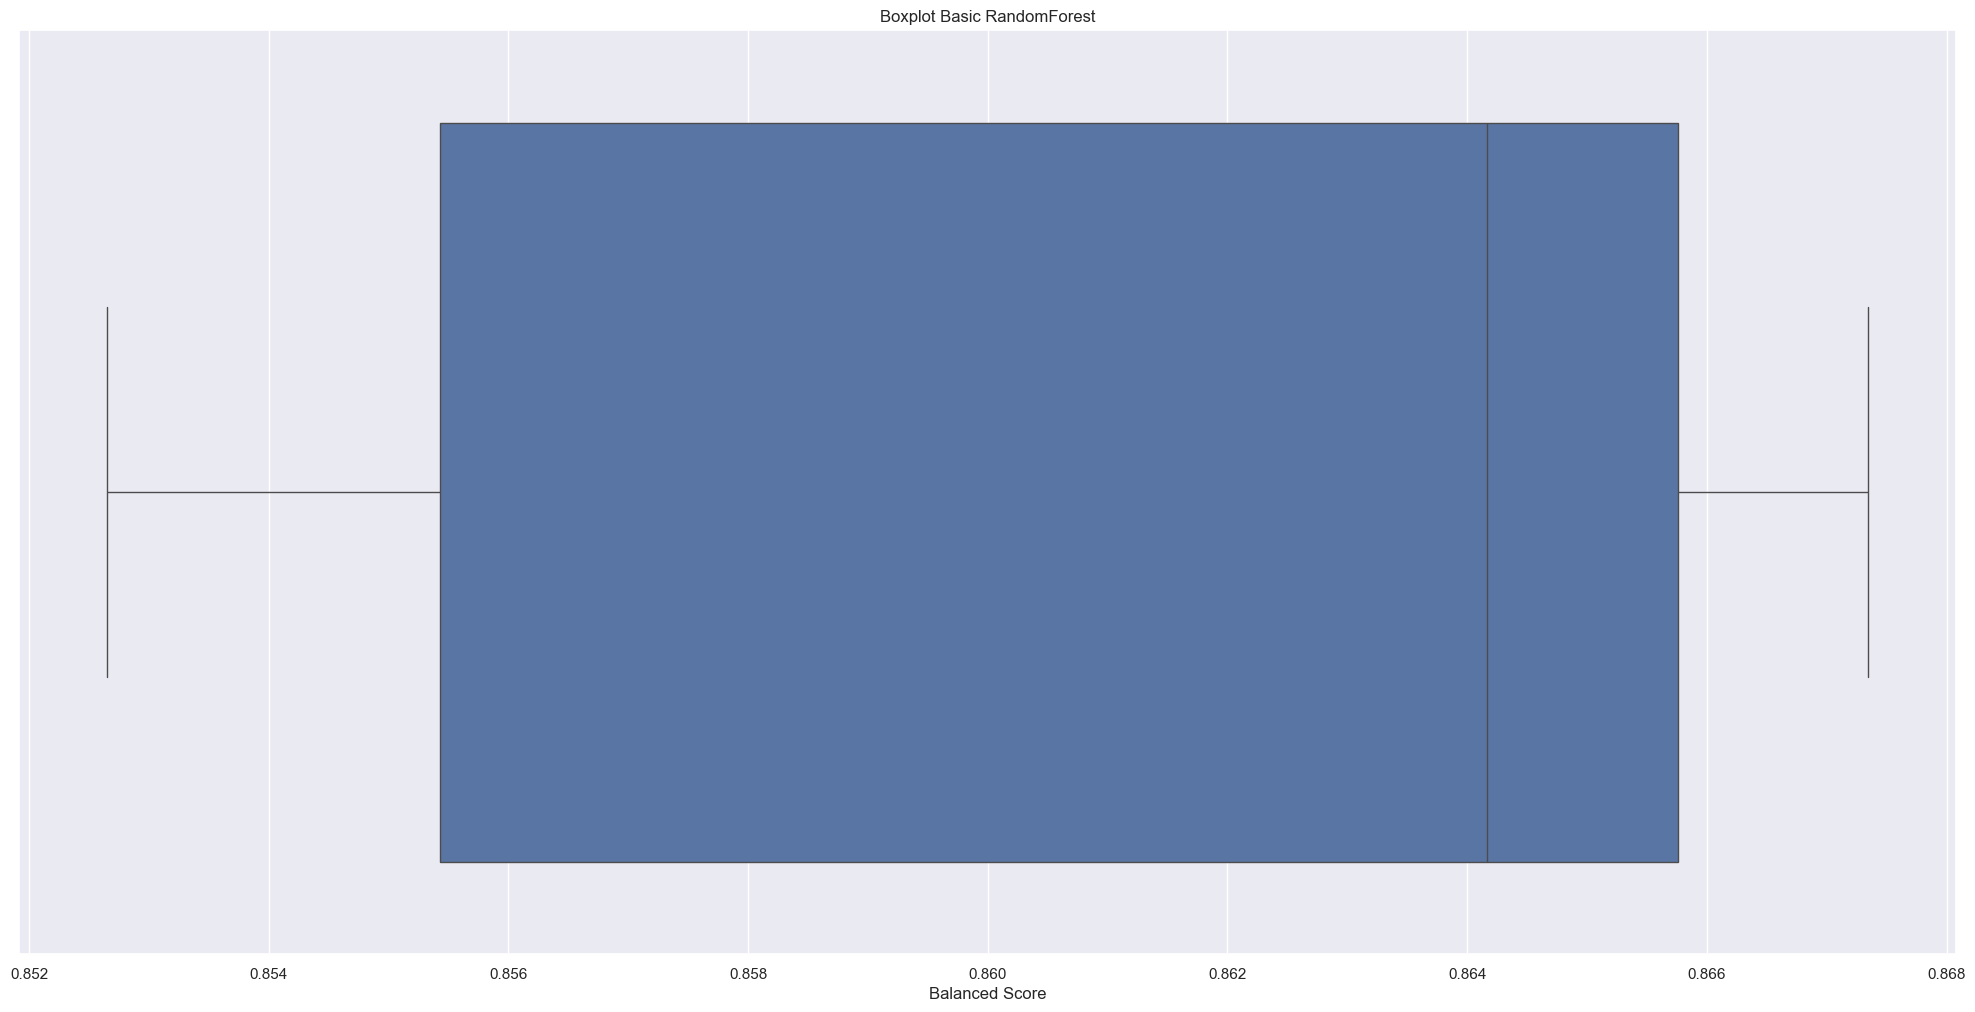

In [62]:
# Cria o boxplot para test_score
sns.boxplot(x=scores_rfc['test_score'])
plt.title('Boxplot Basic RandomForest')
plt.xlabel('Balanced Score')
plt.show()

In [66]:
fpr, tpr, threshold = mt.roc_curve(y_test, y_hat_test)

Text(0, 0.5, 'True Positive Rate')

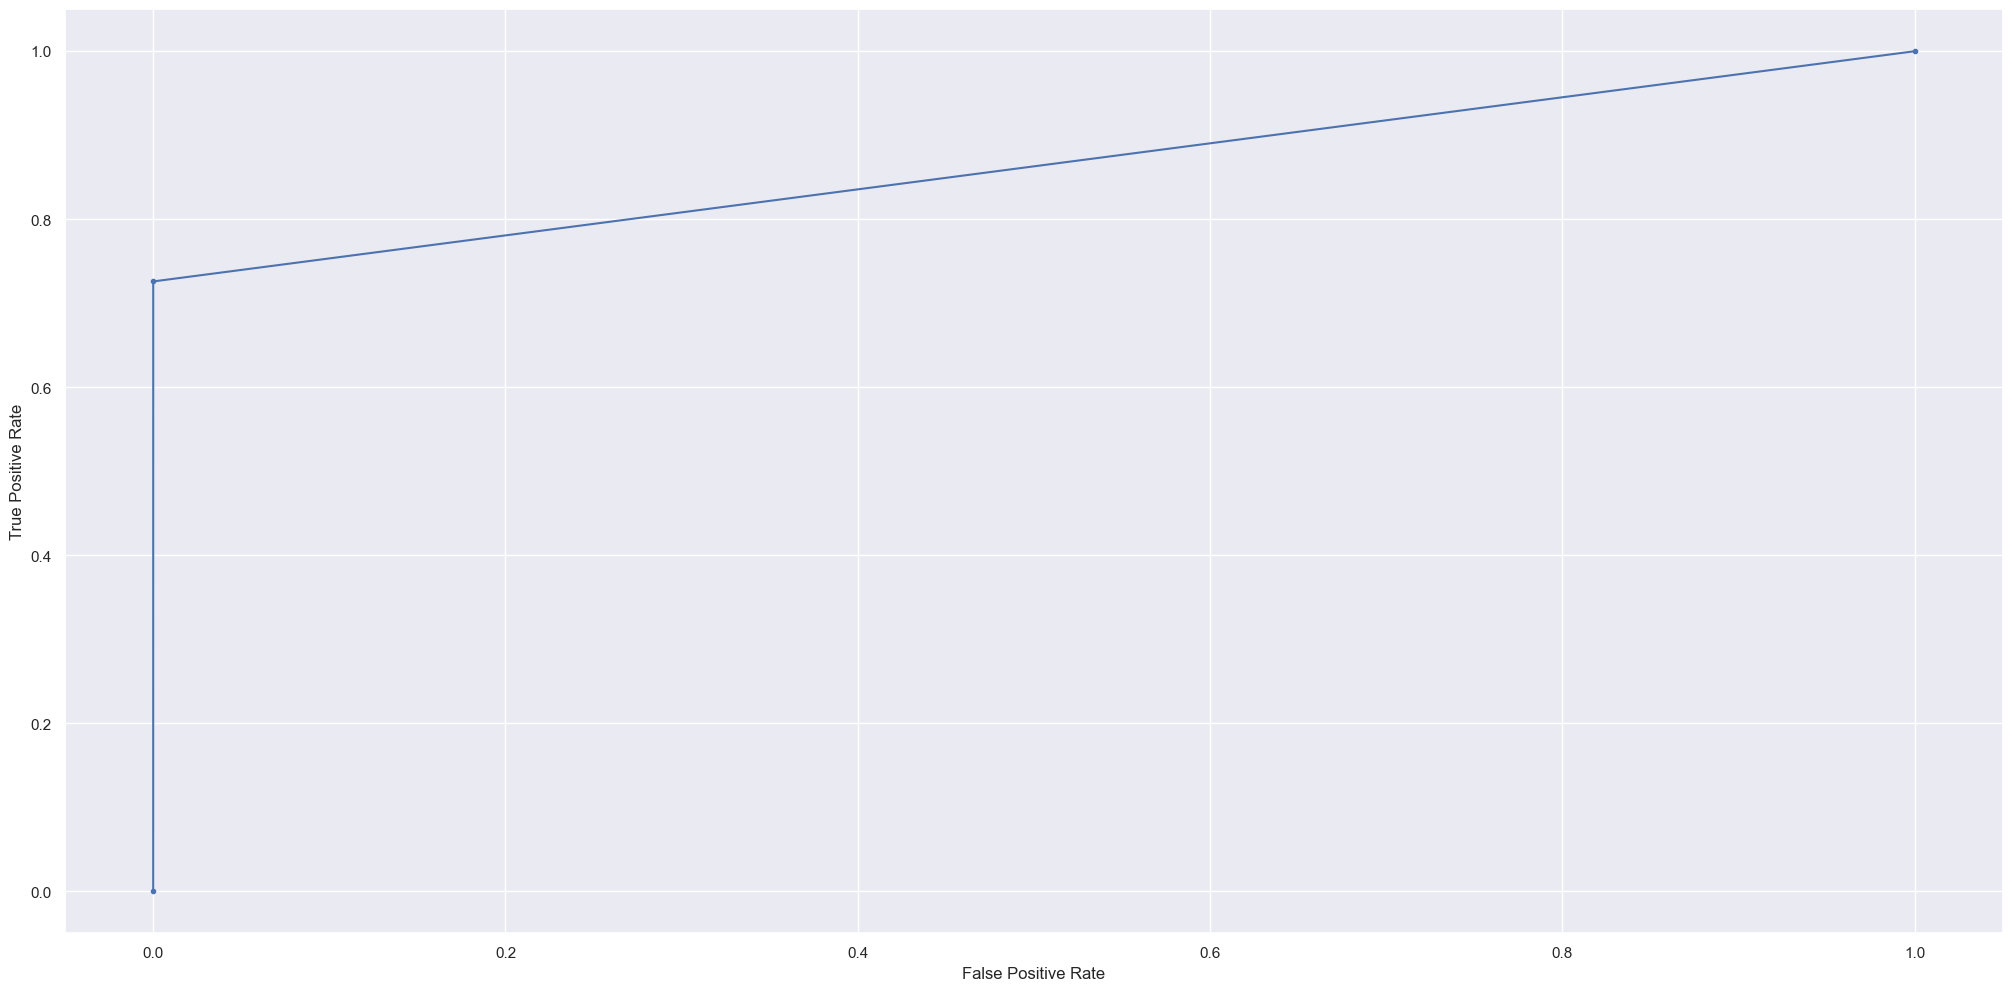

In [67]:
plt.plot (fpr, tpr, marker='.')
plt.xlabel ('False Positive Rate')
plt.ylabel ('True Positive Rate')

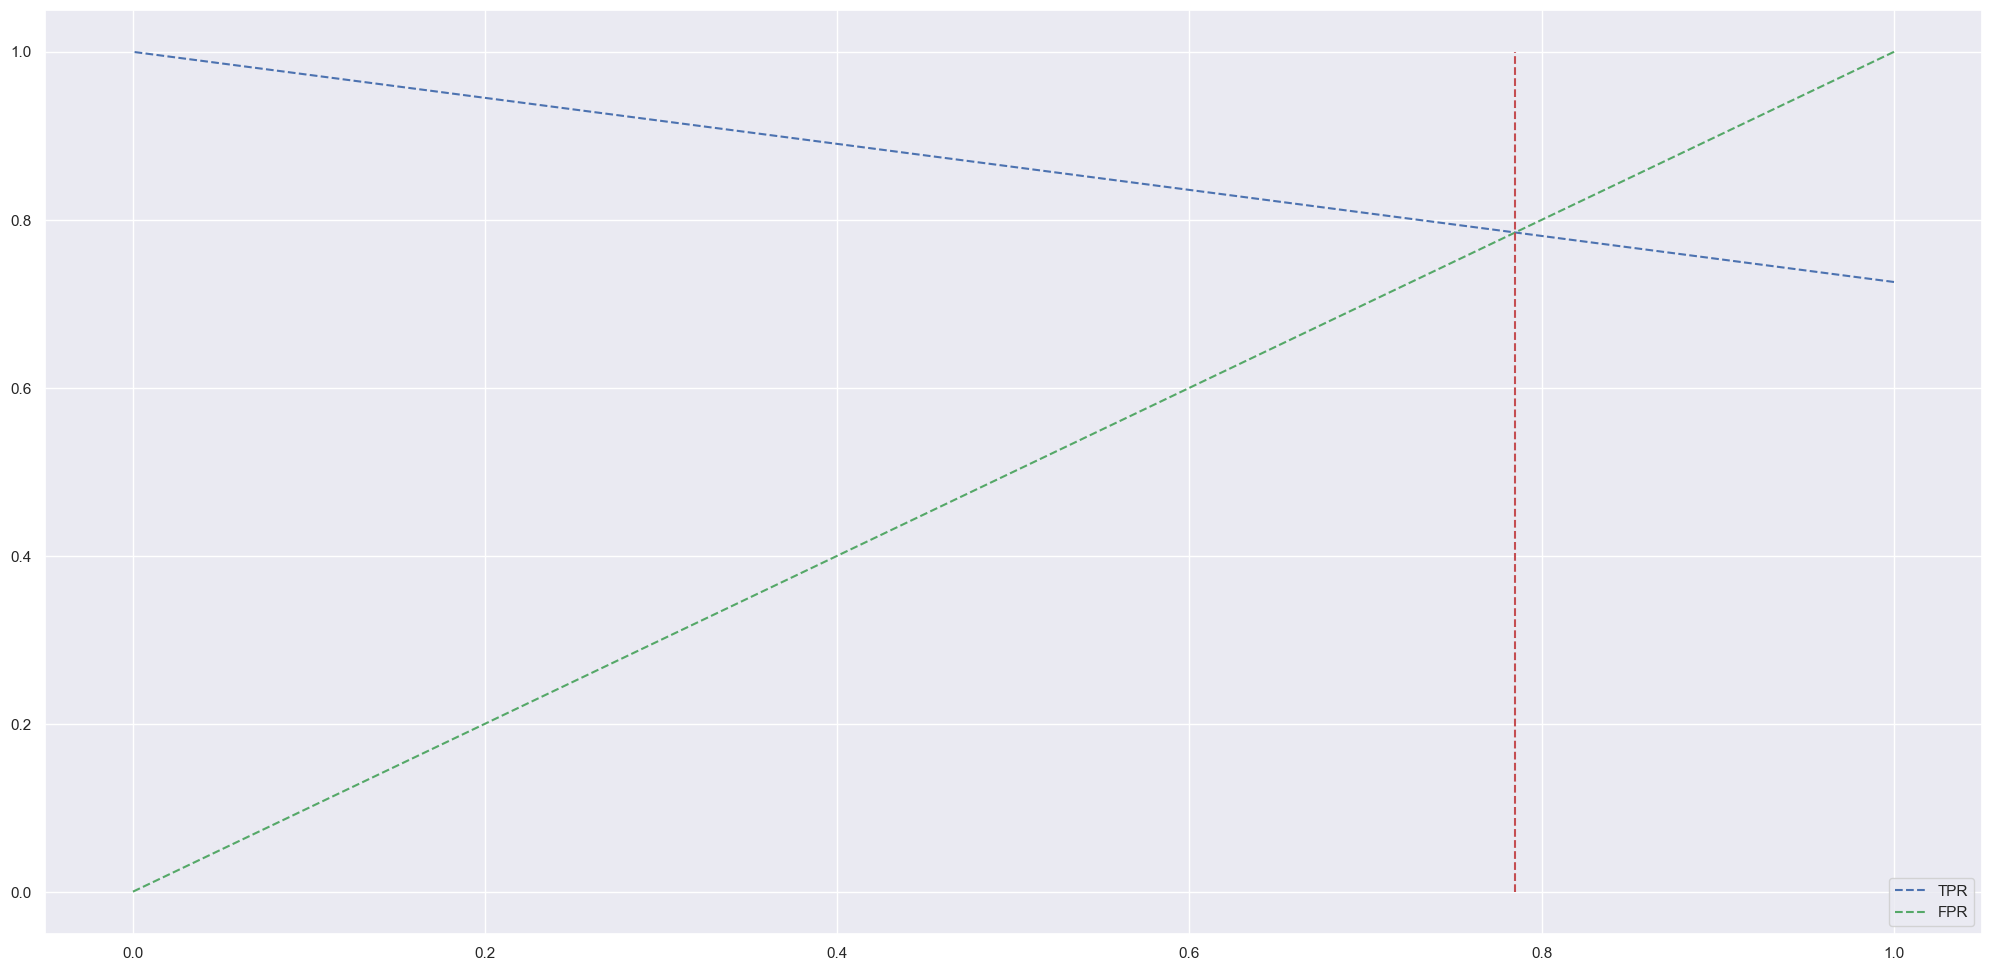

In [74]:
plt.plot (threshold, tpr, 'b--', label='TPR')
plt.plot (threshold, 1-fpr, 'g--', label='FPR')
plt.vlines( 0.785, 0, 1, color='r', linestyles='--')
plt.legend()

### Random Forest Tunned

In [69]:
rf_tunned = TunedThresholdClassifierCV(rfc, scoring="balanced_accuracy").fit(X_train, y_train)

In [70]:
print(f"Cut-off point found at {rf_tunned.best_threshold_:.3f}")

Cut-off point found at 0.010


In [91]:
y_test_tunned = model_pipeline.predict_proba(X_test)

In [92]:
yhat_tunned = y_test_tunned[:,1]
th = 0.010
yhat_tunned_a = [1 if i > th else 0 for i in yhat_tunned]

In [93]:
acc = mt.accuracy_score(y_test, yhat_tunned_a)

precision = mt.precision_score(y_test, yhat_tunned_a)

recall = mt.recall_score(y_test, yhat_tunned_a)

f1_score = mt.f1_score(y_test, yhat_tunned_a)

print(f'Acurácia: {acc}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-Score: {f1_score}')

Acurácia: 0.9932636310396186
Precision: 0.2140485759217194
Recall: 0.9729944400317713
F1-Score: 0.3509023202520768


In [94]:
mt.balanced_accuracy_score(y_test,yhat_tunned_a)

np.float64(0.9831480367609085)

In [95]:
mt.confusion_matrix(y_test,y_hat_test)

array([[671493,     14],
       [   347,    912]])

In [ ]:
# scores_rfc_tunned = cross_validate(rfc, X_train_val, y_train_val, scoring='balanced_accuracy')

In [78]:
# acc = mt.accuracy_score(y_train_val, yhat_test)

# precision = mt.precision_score(y_train_val, yhat_test)

# recall = mt.recall_score(y_train_val, yhat_test)

# f1_score = mt.f1_score(y_train_val, yhat_test)

# print(f'Acurácia: {acc}')
# print(f'Precision: {precision}')
# print(f'Recall: {recall}')
# print(f'F1-Score: {f1_score}')

In [79]:
# fpr, tpr, threshold = mt.roc_curve(y_train_val, y_hat_test)

In [80]:
# plt.plot (fpr, tpr, marker='.')
# plt.xlabel ('False Positive Rate')
# plt.ylabel ('True Positive Rate')

In [81]:
# plt.plot (threshold, tpr, 'b--', label='TPR')
# plt.plot (threshold, 1-fpr, 'g--', label='FPR')
# plt.vlines( 0.65, 0, 1, color='r', linestyles='--')
# plt.legend()

## 7.2 Logistic Regression

In [63]:
# definition

lr = lm.LogisticRegression(max_iter=1000)

# training (fit)

model_pipeline_lr = Pipeline([
    ('drop', dropper),
    ('preprocessing', preprocessing),
    ('model', lr)
])

model_pipeline_lr.fit(X_train, y_train)
# performace

y_hat_test_logistic = model_pipeline_lr.predict(X_test)

acc_lr = mt.accuracy_score(y_test, y_hat_test)

precision_lr = mt.precision_score(y_test, y_hat_test)

recall_lr = mt.recall_score(y_test, y_hat_test)

f1_score_lr = mt.f1_score(y_test, y_hat_test)

print(f'Acurácia: {acc_lr}')
print(f'Precision: {precision_lr}')
print(f'Recall: {recall_lr}')
print(f'F1-Score: {f1_score_lr}')

Acurácia: 0.9994663820704376
Precision: 0.9849137931034483
Recall: 0.7259729944400317
F1-Score: 0.8358481938728852


In [75]:
scores_logistic = cross_validate(
                                model_pipeline_lr,
                                X_train,
                                y_train, 
                                scoring='balanced_accuracy',
                                cv=cv)

In [76]:
scores_logistic

{'fit_time': array([10.91218328,  7.66088915,  7.59616303,  7.0383954 ,  6.84457421]),
 'score_time': array([0.36325169, 0.31944656, 0.31665993, 0.35915041, 0.3146975 ]),
 'test_score': array([0.75175214, 0.74141755, 0.73824712, 0.74183405, 0.75333176])}

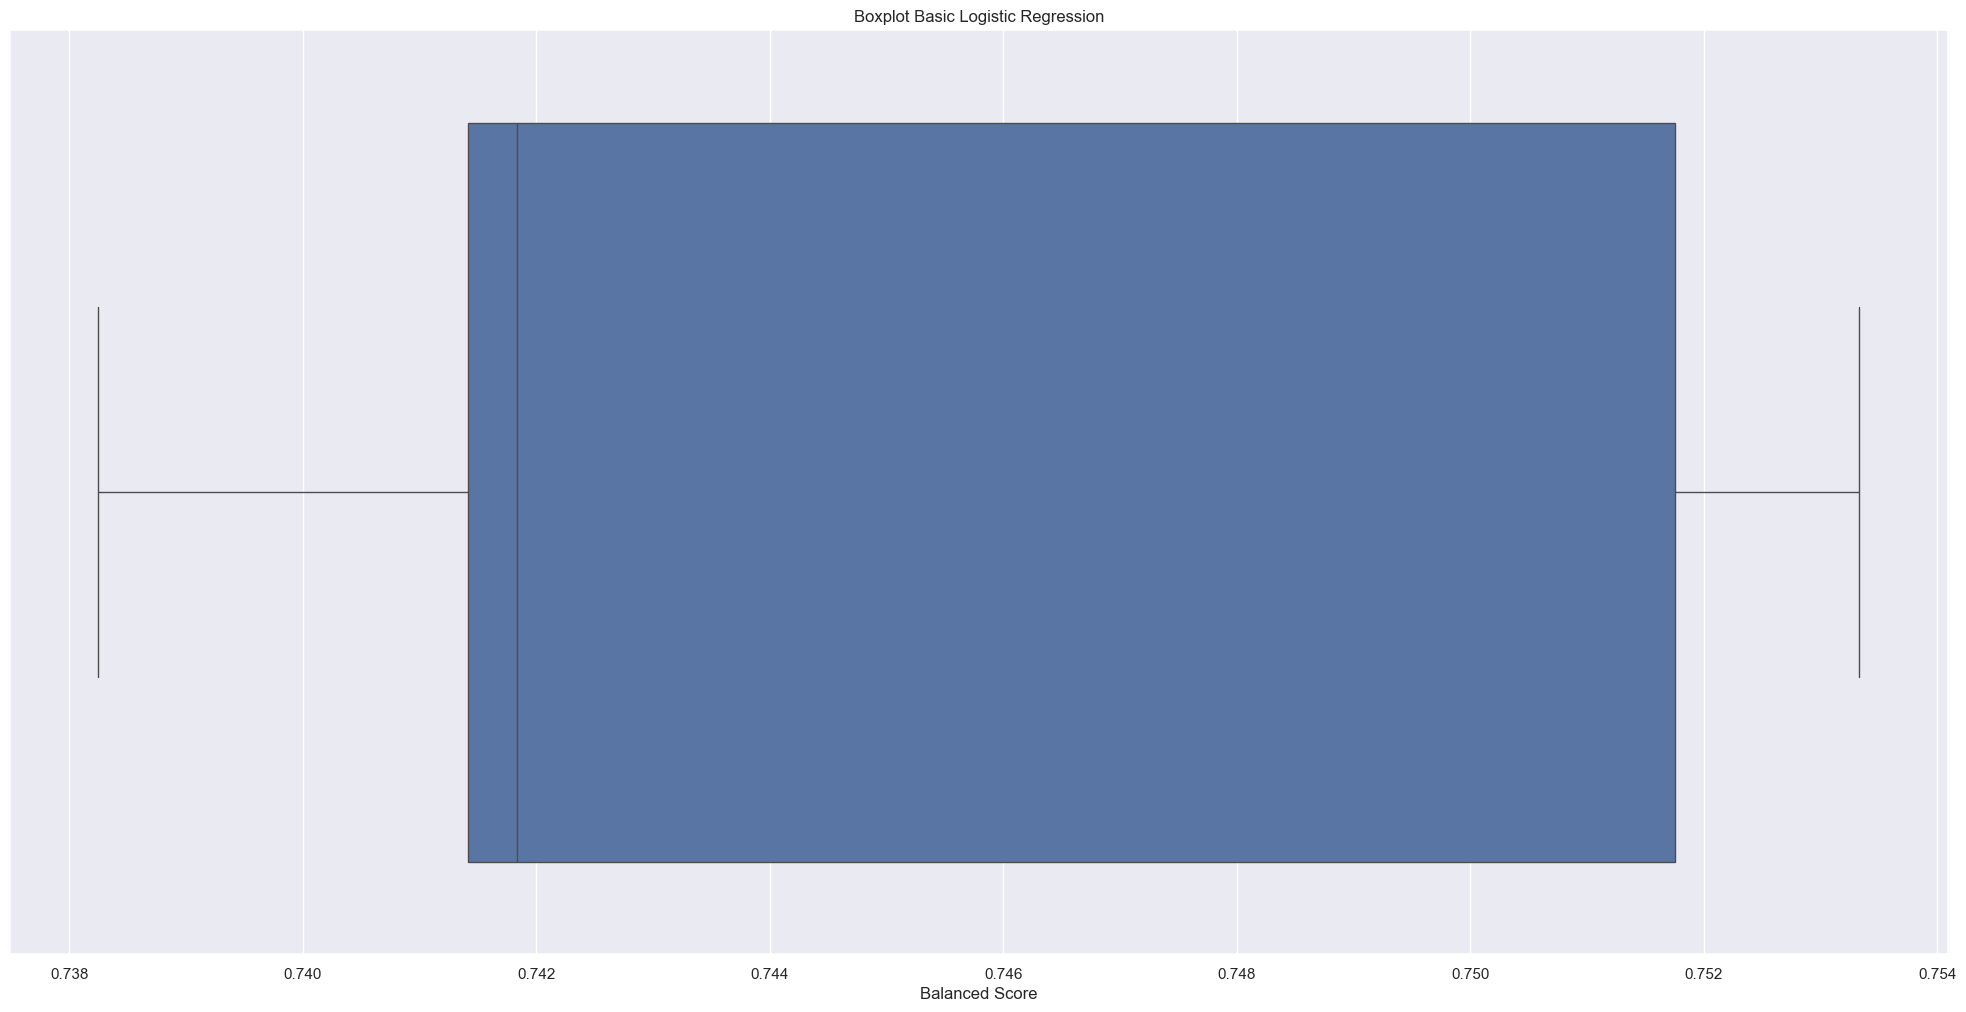

In [77]:
# Cria o boxplot para test_score
sns.boxplot(x=scores_logistic['test_score'])
plt.title('Boxplot Basic Logistic Regression')
plt.xlabel('Balanced Score')
plt.show()

In [78]:
mt.confusion_matrix(y_test, y_hat_test_logistic)

array([[671451,     56],
       [   630,    629]])

In [79]:
fpr, tpr, threshold = mt.roc_curve(y_test, y_hat_test_logistic)

Text(0, 0.5, 'True Positive Rate')

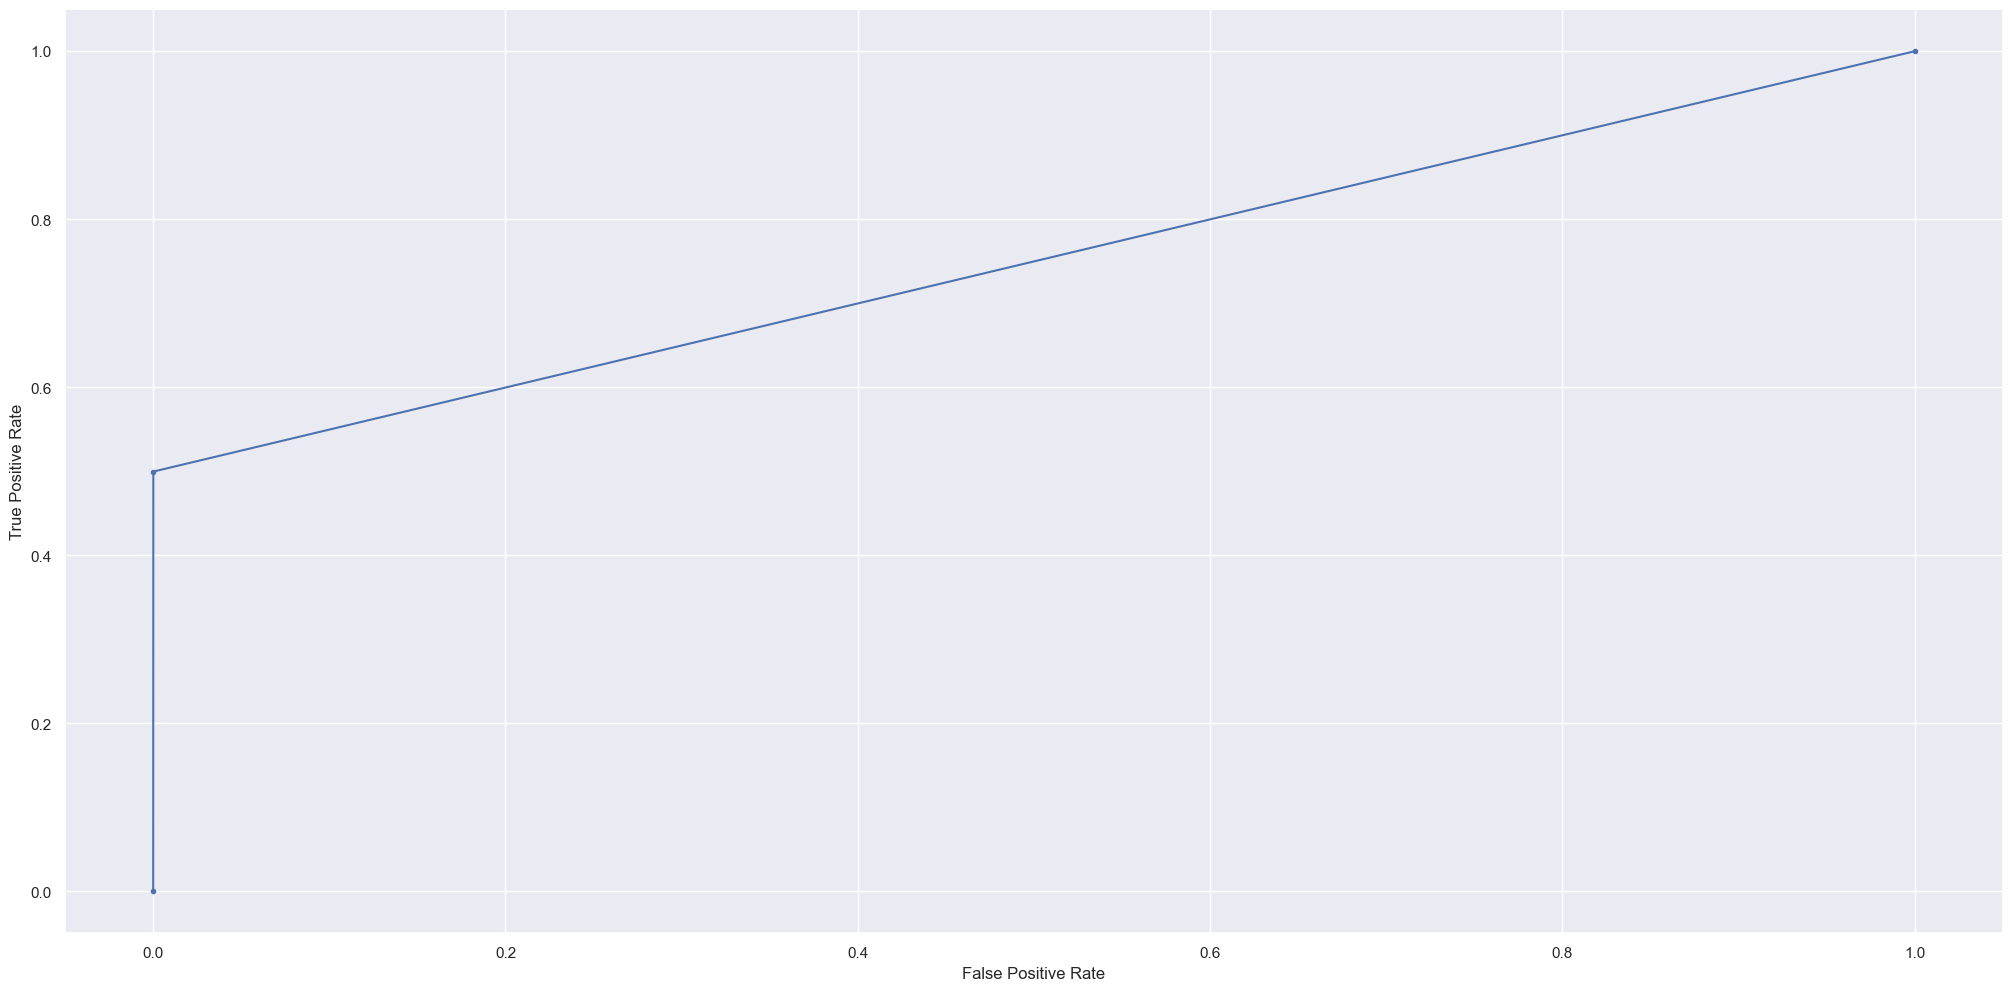

In [80]:
plt.plot (fpr, tpr, marker='.')
plt.xlabel ('False Positive Rate')
plt.ylabel ('True Positive Rate')

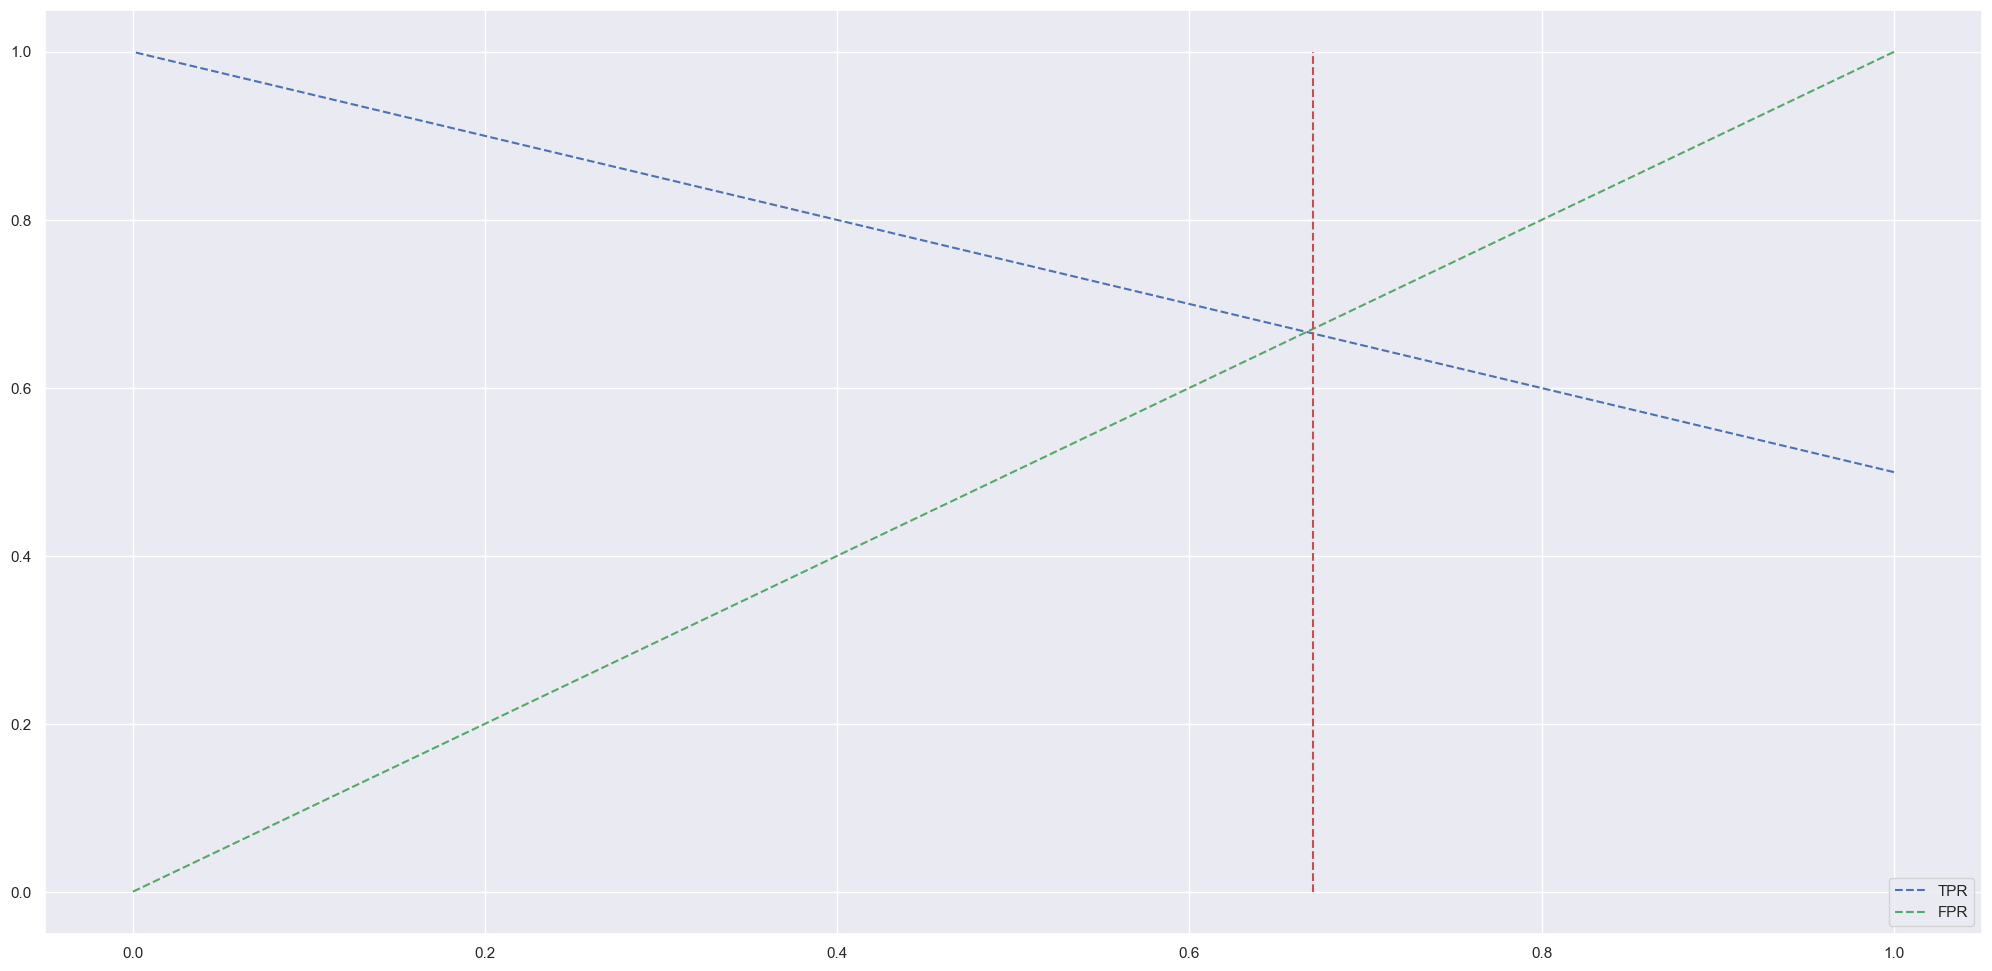

In [83]:
plt.plot (threshold, tpr, 'b--', label='TPR')
plt.plot (threshold, 1-fpr, 'g--', label='FPR')
plt.vlines( 0.67, 0, 1, color='r', linestyles='--')
plt.legend()

In [ ]:
# df_resultados = pd.DataFrame({
#     'Modelo': ['RandomForest'] * len(scores['test_score']) + ['LogisticRegression'] * len(scores_logistic['test_score']),
#     'Test Score': list(scores['test_score']) + list(scores_logistic['test_score'])
# })

# sns.boxplot(x='Test Score', y='Modelo', data=df_resultados)
# plt.title('Comparação de Balanced Accuracy entre Modelos')
# plt.xlabel('Balanced Accuracy')
# plt.grid(True)
# plt.show()

## 7.3 XGBoost

In [84]:
# definition

xgb_model = xgb.XGBClassifier(n_estimators=50, max_depth=15, learning_rate=1, objective='binary:logistic')

# fit
model_pipeline_xgb = Pipeline([
    ('drop', dropper),
    ('preprocessing', preprocessing),
    ('model', xgb_model)
])
model_pipeline_xgb.fit(X_train, y_train)

# performace

y_hat_test_xgb= model_pipeline_xgb.predict(X_test)



In [ ]:
# y_hat_test_xgb = y_hat_test_xgb[:,1]
# th = 0.010
# yhat_tunned_xgb = [1 if i > th else 0 for i in y_hat_test_xgb]

In [85]:
acc = mt.accuracy_score(y_test, y_hat_test_xgb)
precision = mt.precision_score(y_test, y_hat_test_xgb)
recall = mt.recall_score(y_test, y_hat_test_xgb)
f1_score = mt.f1_score(y_test, y_hat_test_xgb)

print(f'Acurácia: {acc}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-Score: {f1_score}')

Acurácia: 0.9971148958181597
Precision: 0.23969465648854962
Recall: 0.2494042891183479
F1-Score: 0.24445309458933437


In [86]:
scores_xgb = cross_validate(model_pipeline_xgb,
                             X_train,
                             y_train,
                             scoring='balanced_accuracy',
                             cv=cv)

In [87]:
scores_xgb

{'fit_time': array([7.97407889, 8.7998693 , 7.97619987, 9.22616529, 7.9435823 ]),
 'score_time': array([0.6102469 , 0.5660181 , 0.5465529 , 0.59787345, 0.50083208]),
 'test_score': array([0.69218356, 0.5237508 , 0.53430058, 0.58023262, 0.51556024])}

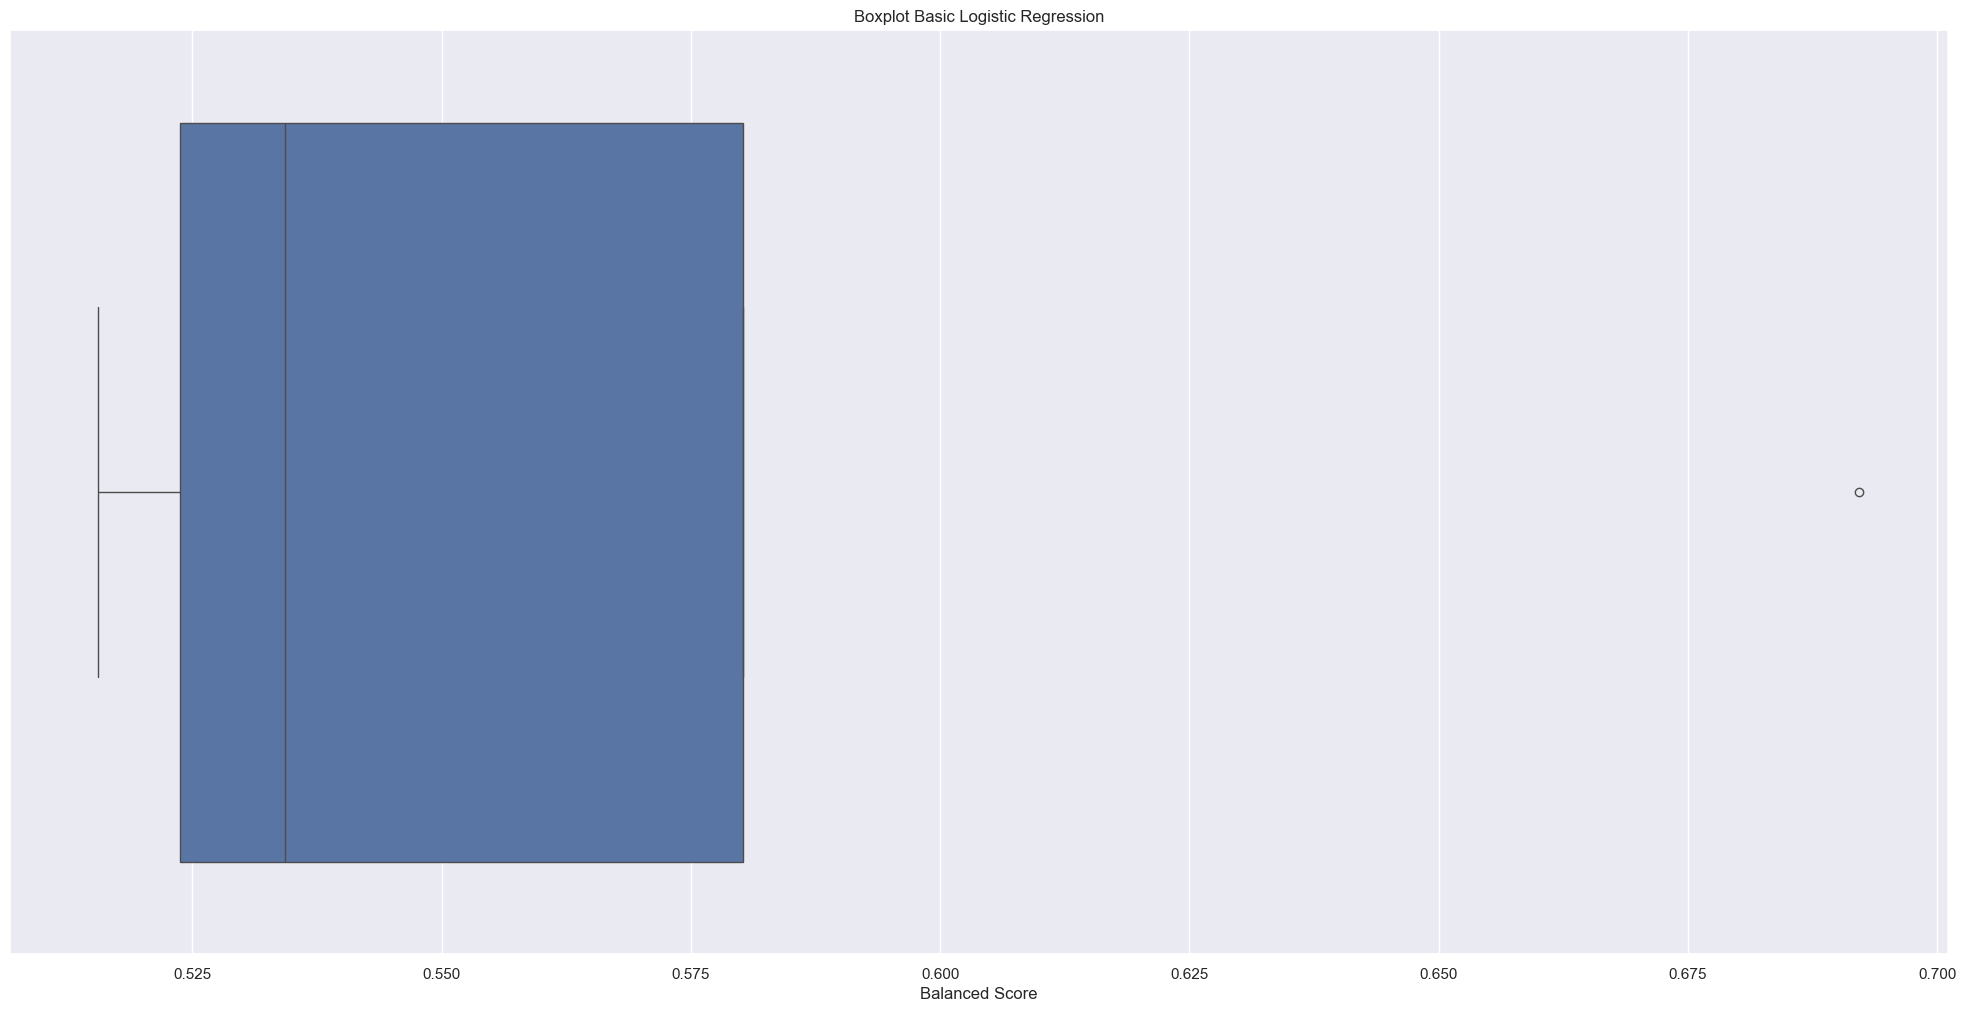

In [88]:
# Cria o boxplot para test_score
sns.boxplot(x=scores_xgb['test_score'])
plt.title('Boxplot Basic Logistic Regression')
plt.xlabel('Balanced Score')
plt.show()

In [89]:
fpr, tpr, threshold = mt.roc_curve(y_test, y_hat_test_xgb)

In [90]:
mt.balanced_accuracy_score(y_test,y_hat_test_xgb)

np.float64(0.6239605290585164)

Text(0, 0.5, 'True Positive Rate')

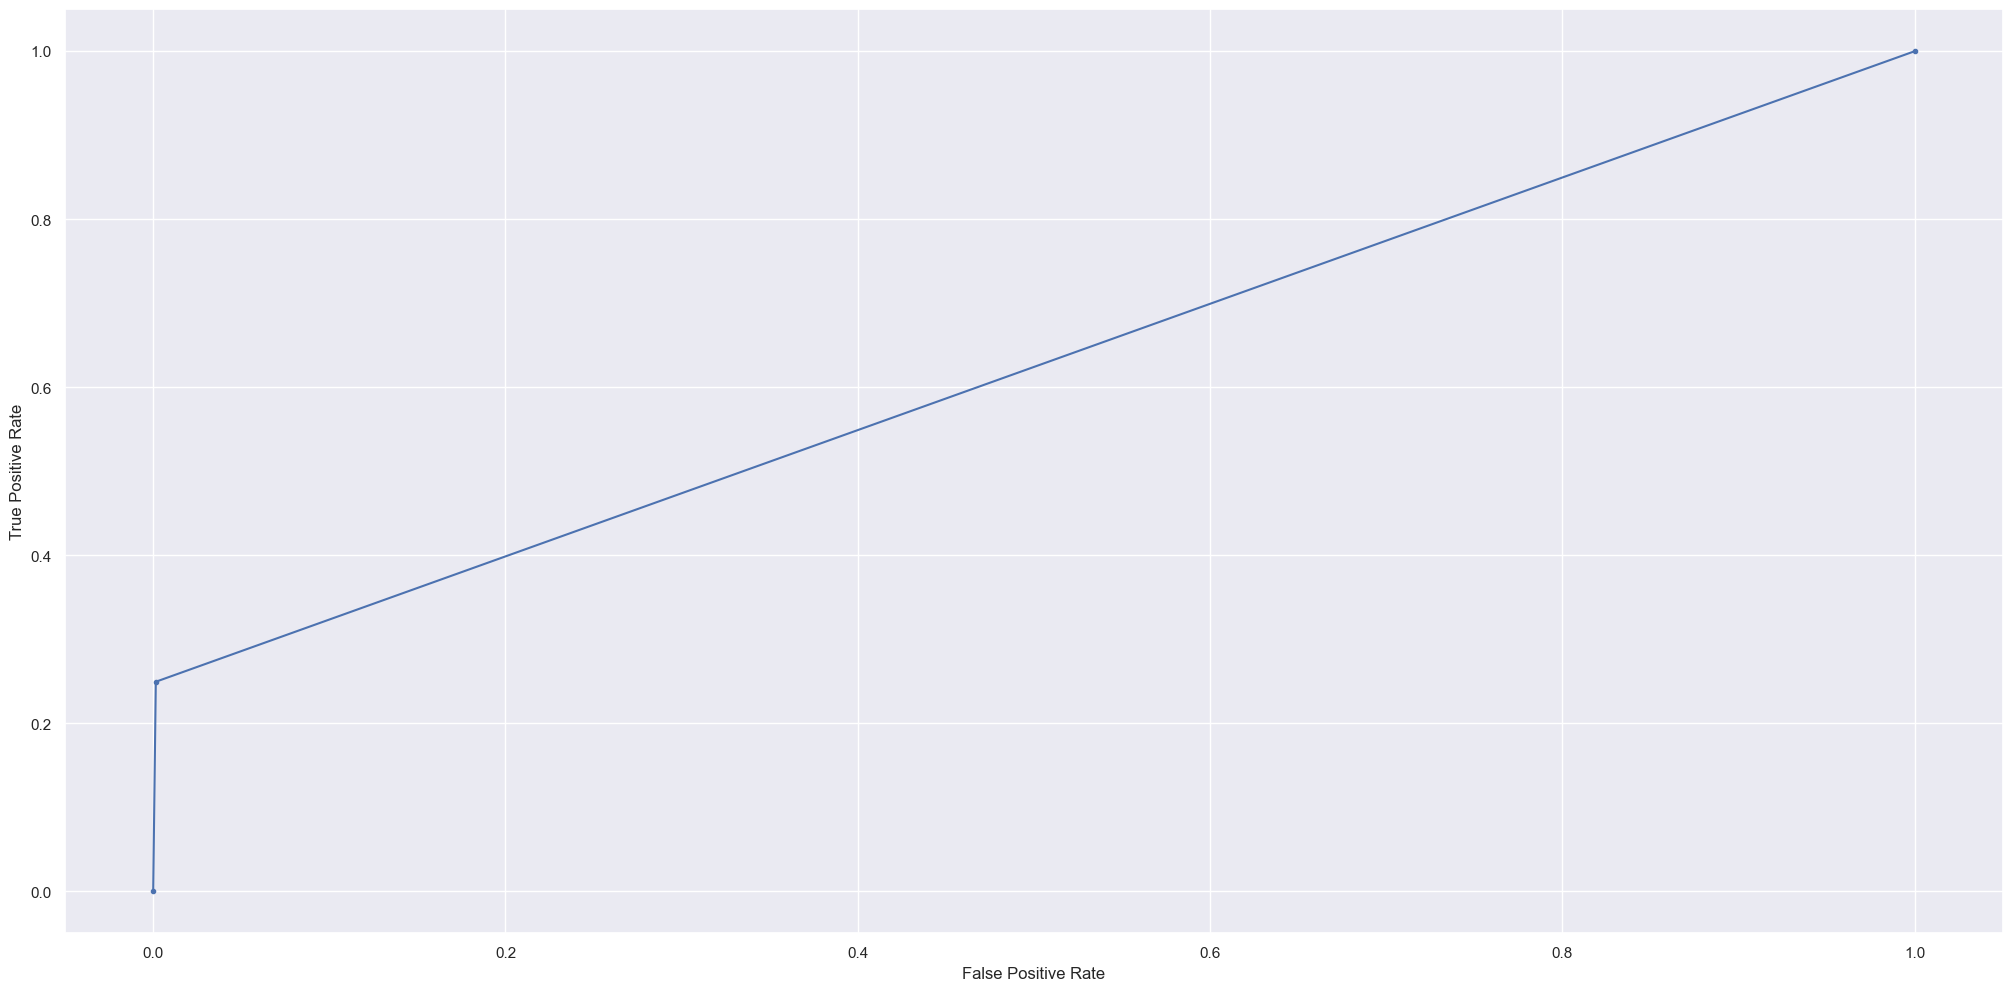

In [91]:
plt.plot (fpr, tpr, marker='.')
plt.xlabel ('False Positive Rate')
plt.ylabel ('True Positive Rate')

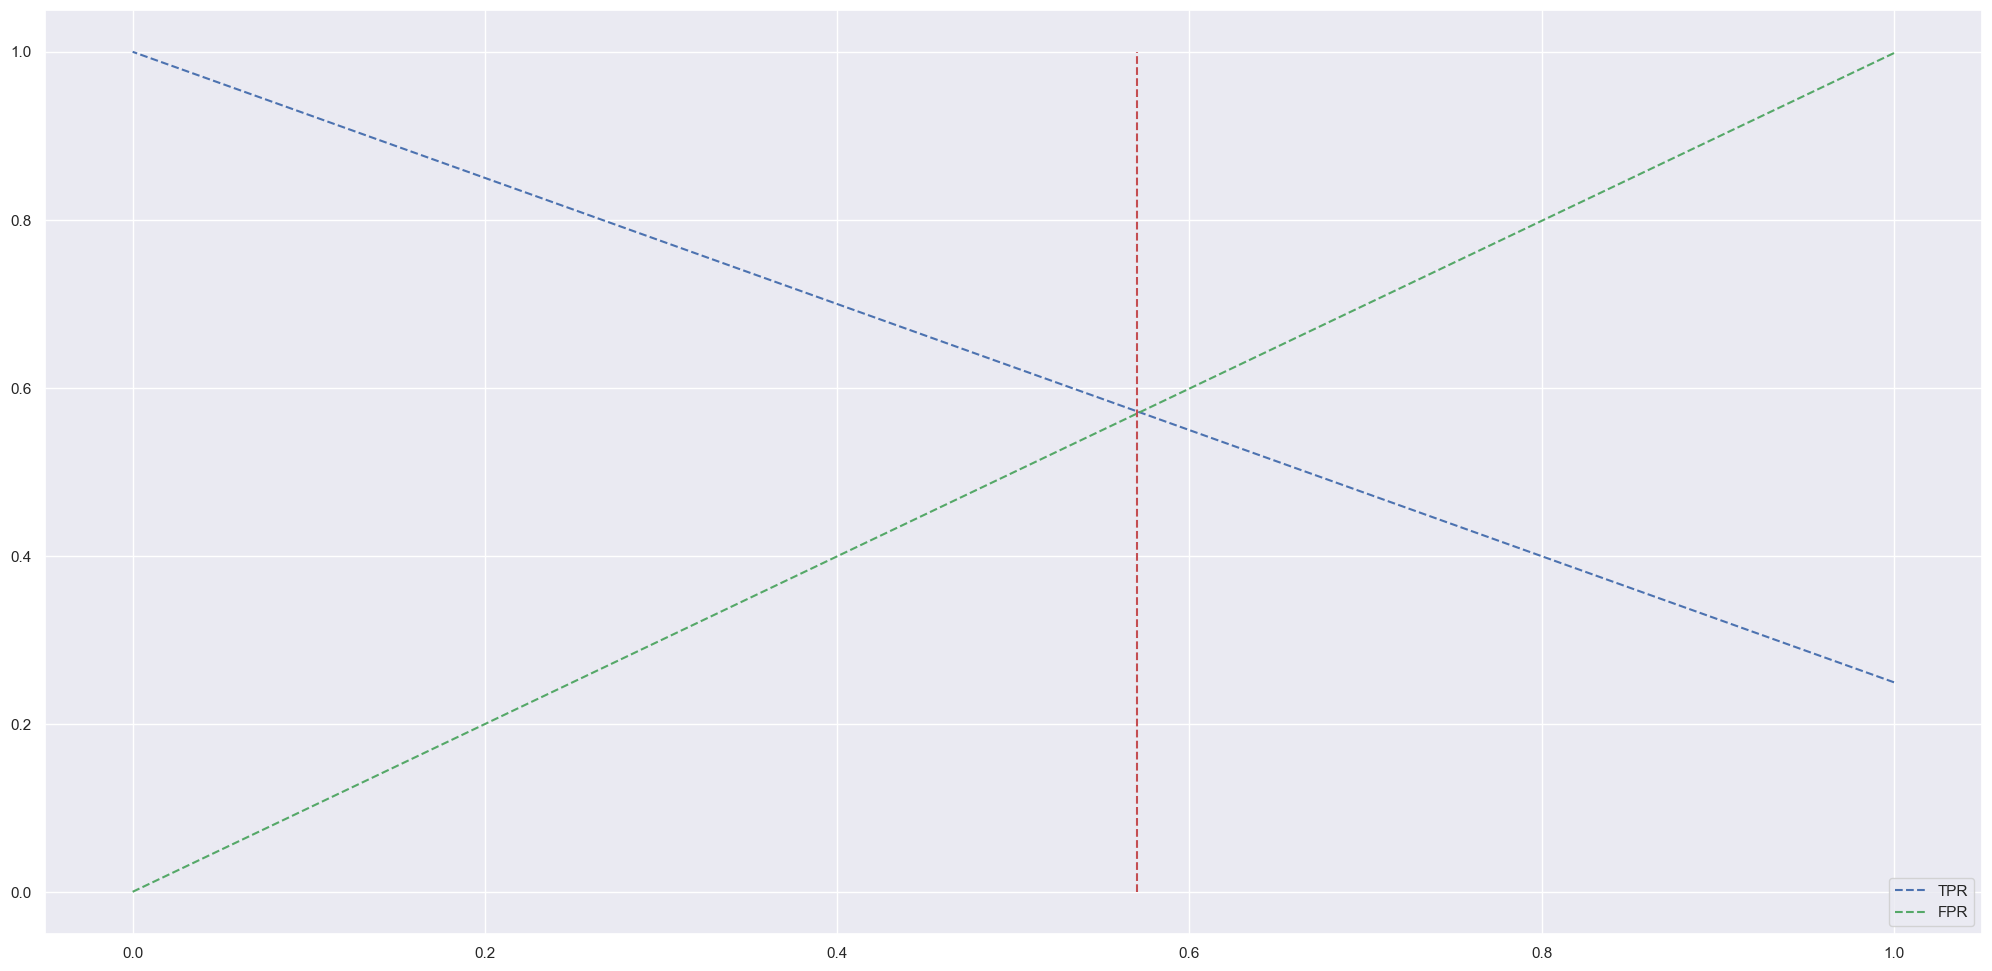

In [92]:
plt.plot (threshold, tpr, 'b--', label='TPR')
plt.plot (threshold, 1-fpr, 'g--', label='FPR')
plt.vlines( 0.57, 0, 1, color='r', linestyles='--')
plt.legend()

In [93]:
mt.confusion_matrix(y_test, y_hat_test_xgb)

array([[670511,    996],
       [   945,    314]])

## 7.4 CATBoost

In [64]:
# definition

cat_model = cat.CatBoostClassifier(max_depth=15, learning_rate=1)


model_pipeline_cat = Pipeline([
    ('drop', dropper),
    ('preprocessing', preprocessing),
    ('model', cat_model)
])
model_pipeline_cat.fit(X_train, y_train)
# performace

y_hat_test_cat= model_pipeline_cat.predict(X_test)

0:	learn: 0.0056148	total: 745ms	remaining: 12m 24s
1:	learn: 0.0032586	total: 3.05s	remaining: 25m 23s
2:	learn: 0.0025686	total: 5.3s	remaining: 29m 21s
3:	learn: 0.0022995	total: 7.62s	remaining: 31m 36s
4:	learn: 0.0019910	total: 9.91s	remaining: 32m 52s
5:	learn: 0.0018957	total: 12.4s	remaining: 34m 15s
6:	learn: 0.0017892	total: 14.9s	remaining: 35m 12s
7:	learn: 0.0017580	total: 17.2s	remaining: 35m 33s
8:	learn: 0.0016122	total: 19.3s	remaining: 35m 28s
9:	learn: 0.0015604	total: 21.5s	remaining: 35m 26s
10:	learn: 0.0015109	total: 23.7s	remaining: 35m 27s
11:	learn: 0.0014785	total: 25.8s	remaining: 35m 25s
12:	learn: 0.0014544	total: 27.8s	remaining: 35m 9s
13:	learn: 0.0013738	total: 30.1s	remaining: 35m 18s
14:	learn: 0.0013368	total: 32s	remaining: 35m
15:	learn: 0.0013026	total: 34.3s	remaining: 35m 10s
16:	learn: 0.0012854	total: 36.7s	remaining: 35m 23s
17:	learn: 0.0012630	total: 39.2s	remaining: 35m 38s
18:	learn: 0.0012432	total: 41.2s	remaining: 35m 28s
19:	learn: 

In [ ]:
# y_hat_test_cat = y_hat_test_cat[:,1]
# th = 0.010
# yhat_tunned_cat = [1 if i > th else 0 for i in y_hat_test_cat]

In [103]:
acc_cat = mt.accuracy_score(y_test, y_hat_test_cat)
precision_cat = mt.precision_score(y_test, y_hat_test_cat)
recall_cat = mt.recall_score(y_test, y_hat_test_cat)
f1_score_cat = mt.f1_score(y_test, y_hat_test_cat)
balanced_score_cat = mt.balanced_accuracy_score(y_test,y_hat_test_cat)

print(f'Acurácia: {acc_cat}')
print(f'Precision: {precision_cat}')
print(f'Recall: {recall_cat}')
print(f'F1-Score: {f1_score_cat}')
print(f'Acurácia Balanceada: {balanced_score_cat}')

Acurácia: 0.9994425996557496
Precision: 0.8816925734024179
Recall: 0.8109610802223988
F1-Score: 0.8448489863467108
Acurácia Balanceada: 0.9053785307501652


In [96]:
scores_cat = cross_validate(model_pipeline_cat,
                             X_train,
                             y_train,
                             scoring='balanced_accuracy',
                             cv=cv)

0:	learn: 0.0135988	total: 245ms	remaining: 4m 4s
1:	learn: 0.0034263	total: 1.78s	remaining: 14m 47s
2:	learn: 0.0029224	total: 3.22s	remaining: 17m 50s
3:	learn: 0.0024897	total: 4.66s	remaining: 19m 20s
4:	learn: 0.0022306	total: 6.12s	remaining: 20m 17s
5:	learn: 0.0021124	total: 7.57s	remaining: 20m 54s
6:	learn: 0.0020253	total: 9.06s	remaining: 21m 24s
7:	learn: 0.0018578	total: 10.5s	remaining: 21m 41s
8:	learn: 0.0017251	total: 11.9s	remaining: 21m 47s
9:	learn: 0.0016429	total: 13.4s	remaining: 22m 2s
10:	learn: 0.0015831	total: 14.9s	remaining: 22m 15s
11:	learn: 0.0015211	total: 16.4s	remaining: 22m 29s
12:	learn: 0.0014841	total: 17.9s	remaining: 22m 37s
13:	learn: 0.0014248	total: 19.5s	remaining: 22m 51s
14:	learn: 0.0014055	total: 21s	remaining: 22m 58s
15:	learn: 0.0013477	total: 22.4s	remaining: 23m
16:	learn: 0.0013099	total: 24s	remaining: 23m 6s
17:	learn: 0.0012657	total: 25.5s	remaining: 23m 12s
18:	learn: 0.0012264	total: 27.1s	remaining: 23m 18s
19:	learn: 0.00

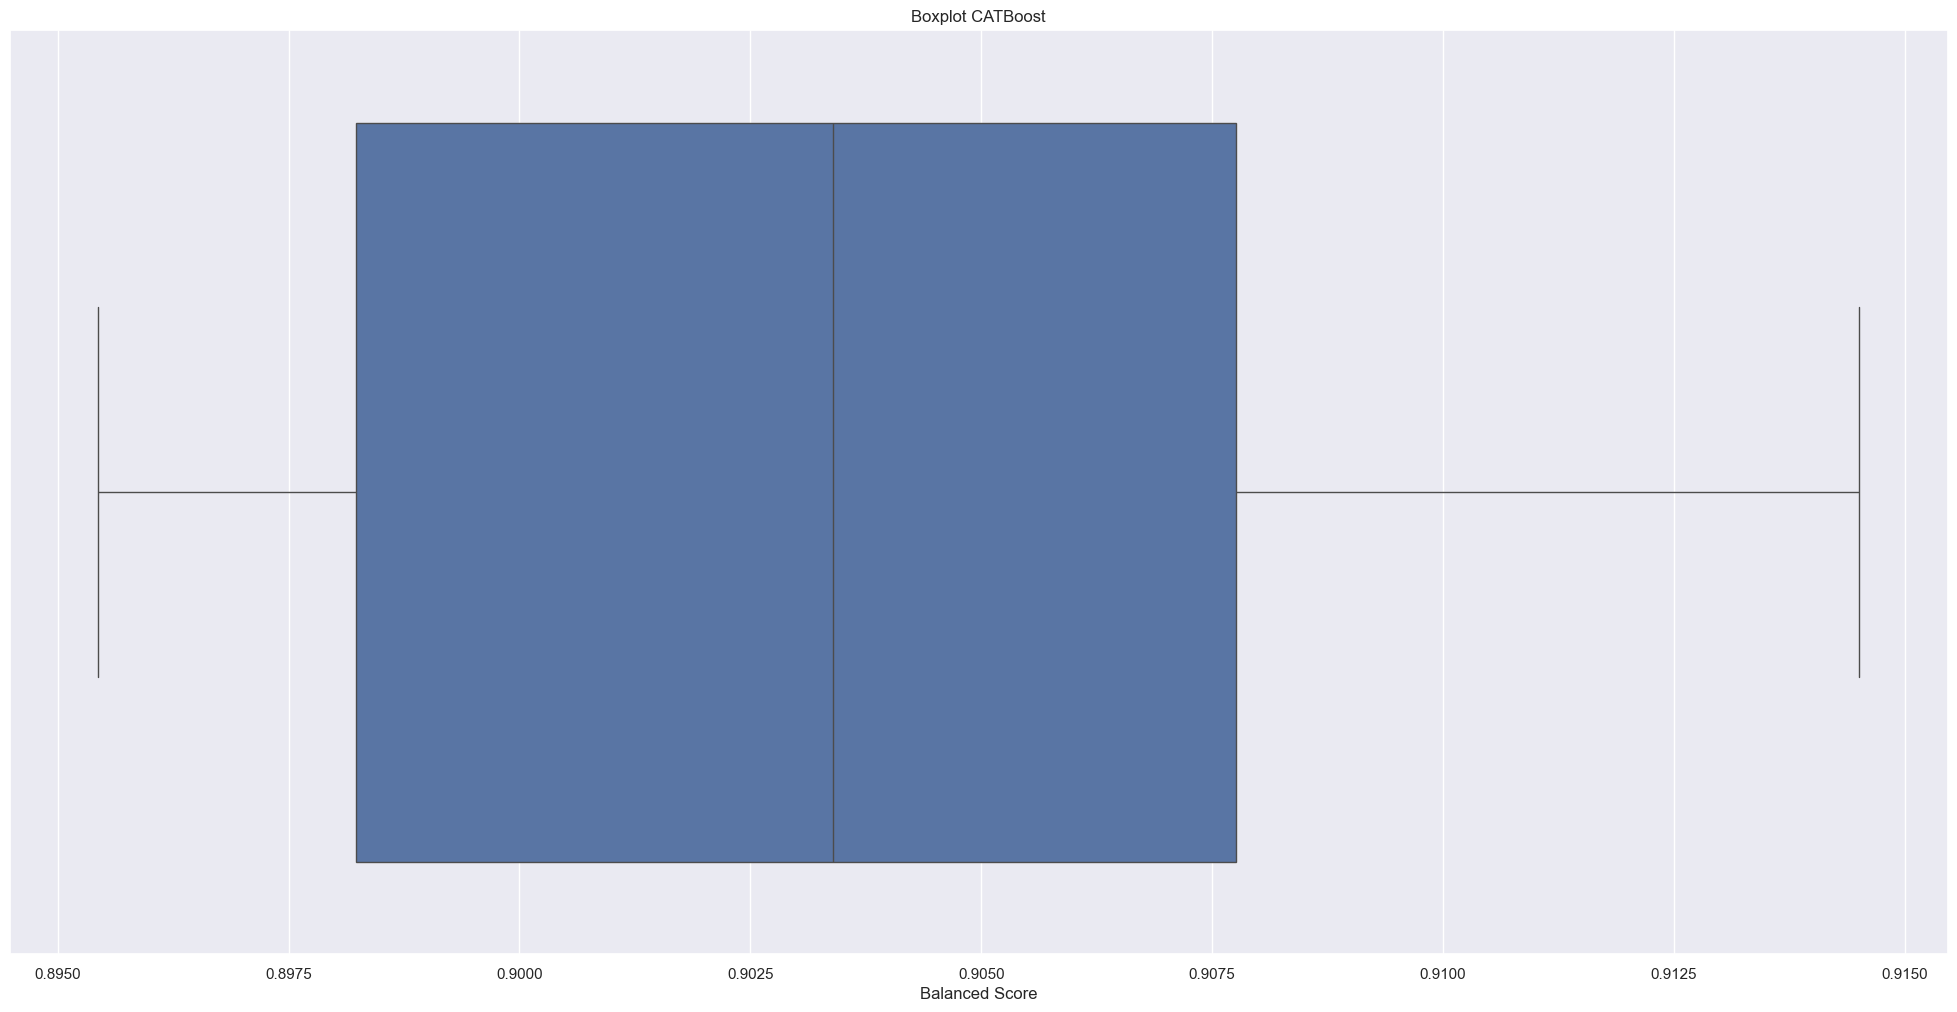

In [97]:
# Cria o boxplot para test_score
sns.boxplot(x=scores_cat['test_score'])
plt.title('Boxplot CATBoost')
plt.xlabel('Balanced Score')
plt.show()

In [98]:
fpr, tpr, threshold = mt.roc_curve(y_test, y_hat_test_cat)

Text(0, 0.5, 'True Positive Rate')

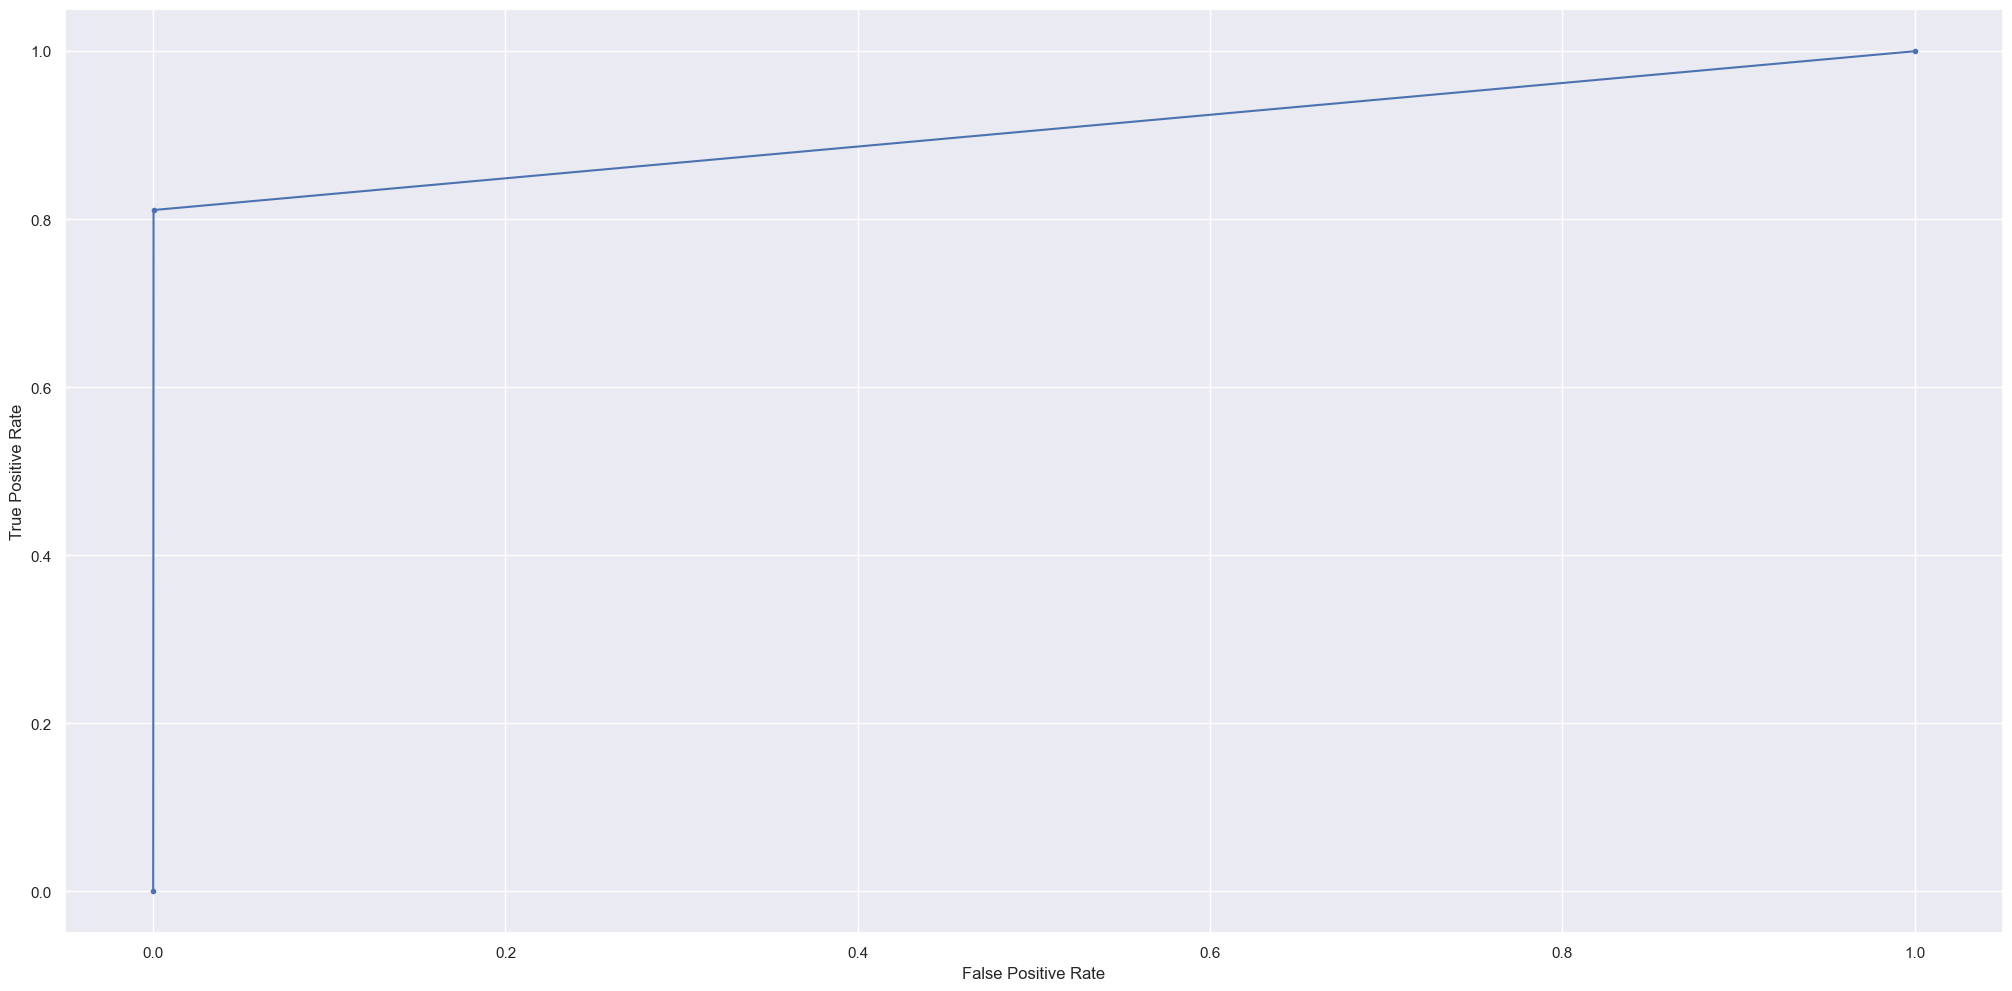

In [99]:
plt.plot (fpr, tpr, marker='.')
plt.xlabel ('False Positive Rate')
plt.ylabel ('True Positive Rate')

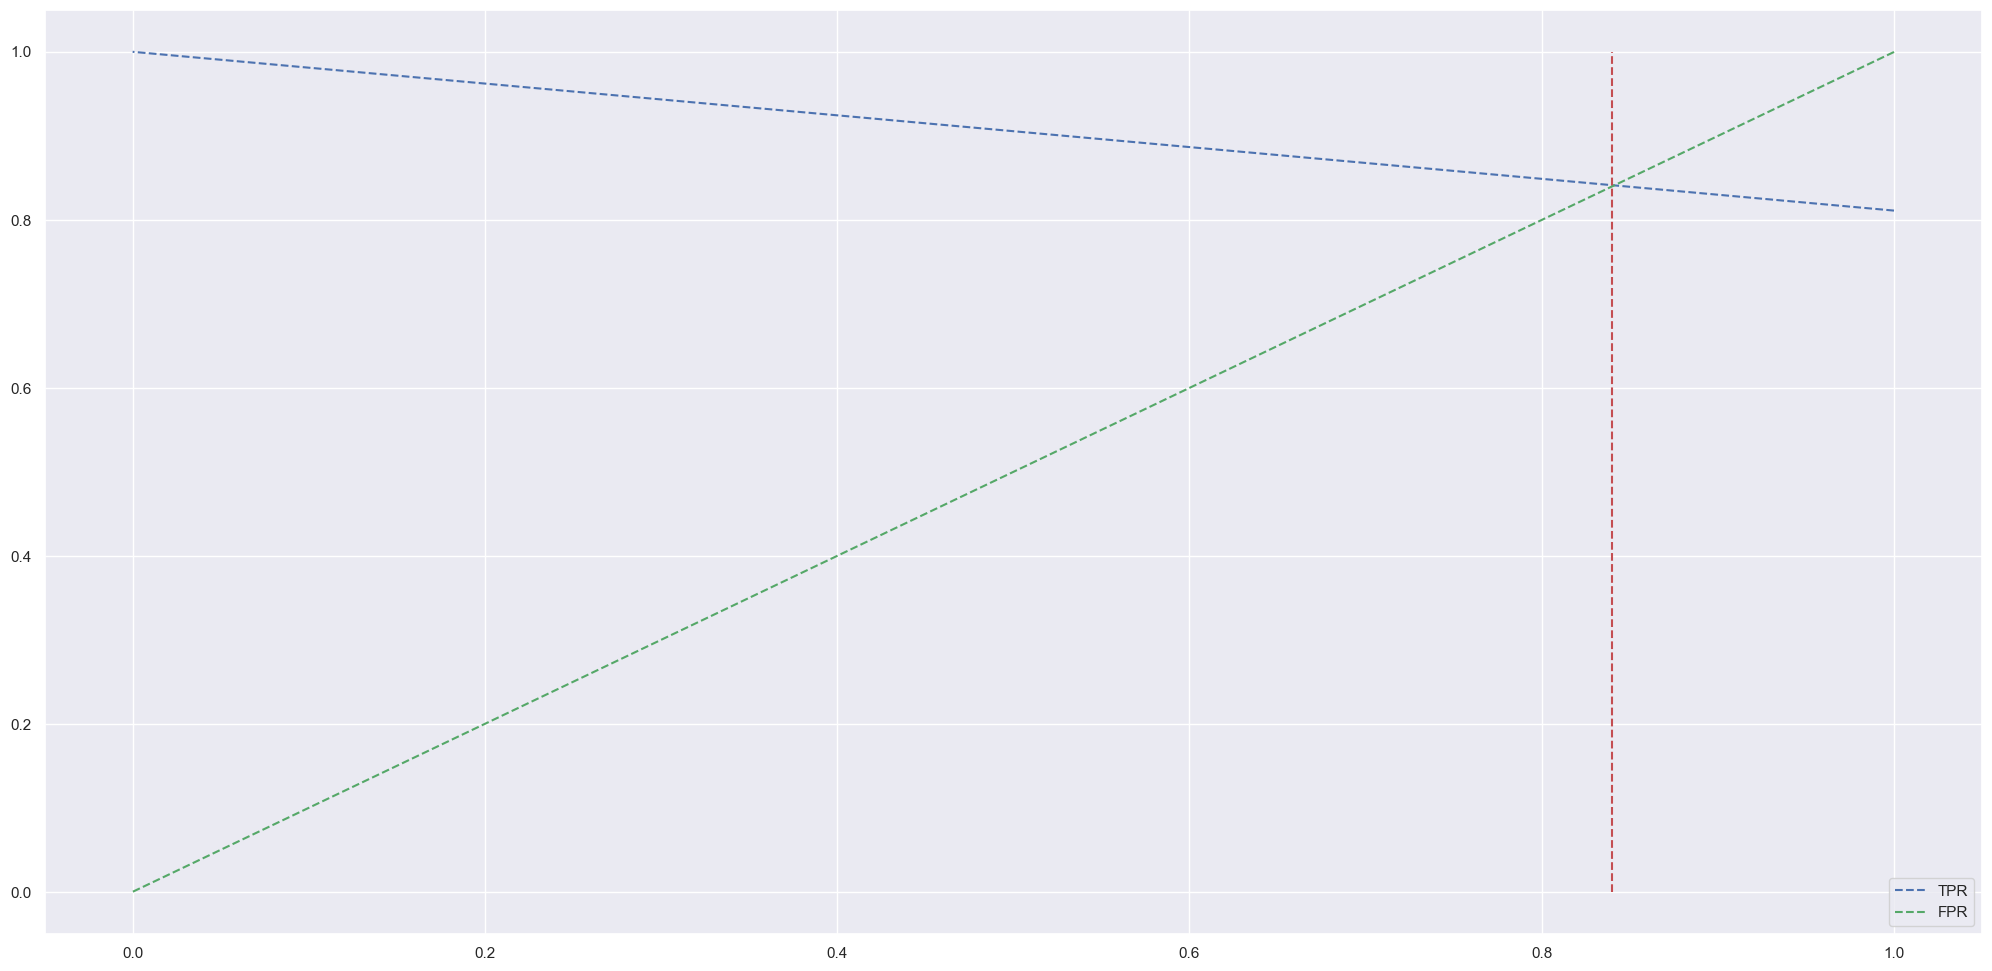

In [100]:
plt.plot (threshold, tpr, 'b--', label='TPR')
plt.plot (threshold, 1-fpr, 'g--', label='FPR')
plt.vlines( 0.84, 0, 1, color='r', linestyles='--')
plt.legend()

In [102]:
mt.confusion_matrix(y_test, y_hat_test_cat)

array([[671370,    137],
       [   238,   1021]])

# 8.0 Evaluations

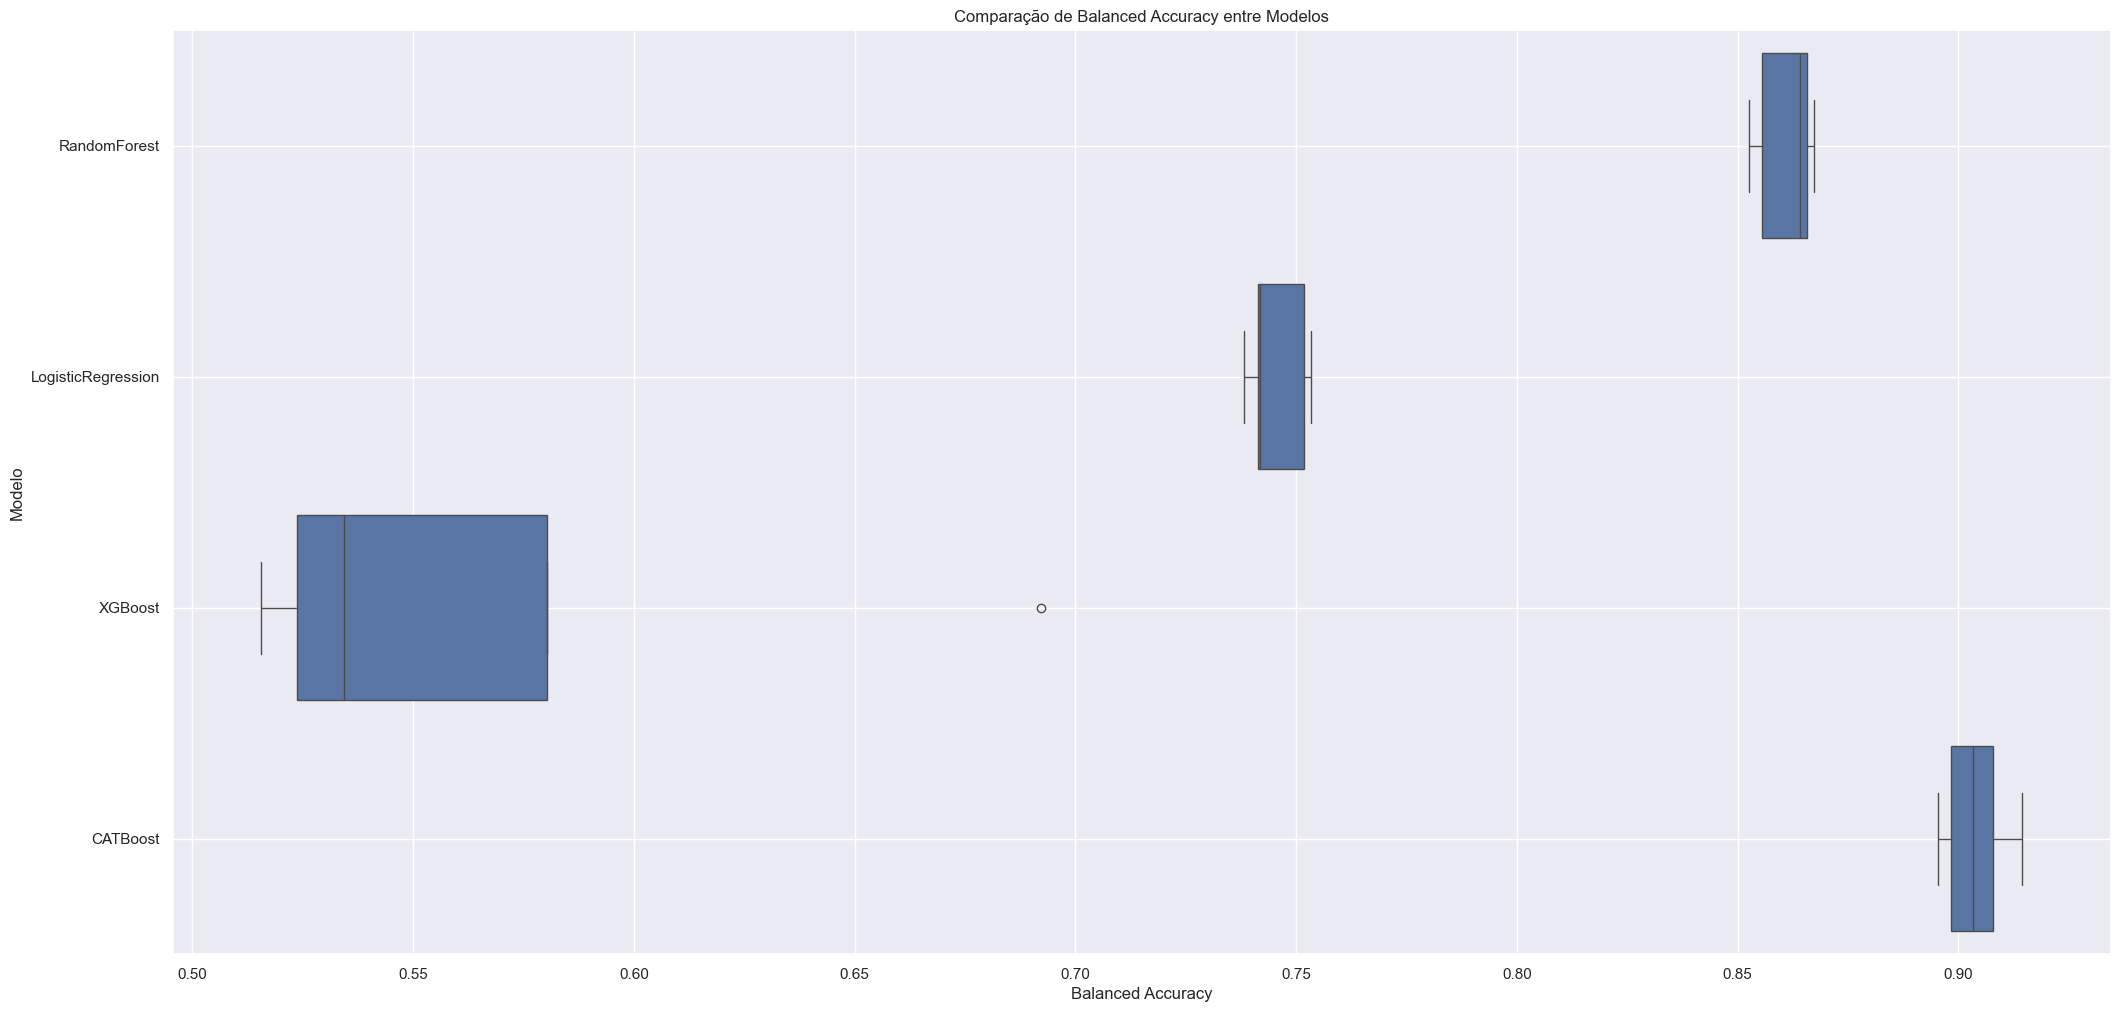

In [101]:
df_resultados = pd.DataFrame({
    'Modelo': ['RandomForest'] * len(scores_rfc['test_score']) + ['LogisticRegression'] * len(scores_logistic['test_score']) +
            ['XGBoost'] * len(scores_xgb['test_score']) + ['CATBoost'] * len(scores_cat['test_score']),
    'Test Score': list(scores_rfc['test_score']) + list(scores_logistic['test_score']) + list(scores_xgb['test_score']) + list(scores_cat['test_score'])
})

sns.boxplot(x='Test Score', y='Modelo', data=df_resultados)
plt.title('Comparação de Balanced Accuracy entre Modelos')
plt.xlabel('Balanced Accuracy')
plt.grid(True)
plt.show()

In [174]:
teste = X_test.copy()
teste['is_fraud'] = y_test
teste['is_fraud_model_base'] = y_hat_test_logistic
teste['is_fraud_model_cat'] = y_hat_test_cat

In [175]:
df_TP_cat = teste.loc[(teste['is_fraud'] == 0) & (teste['is_fraud_model_cat'] == 0), :]
df_TN_cat = teste.loc[(teste['is_fraud'] == 1) & (teste['is_fraud_model_cat'] == 1), :]
df_FP_cat = teste.loc[(teste['is_fraud'] == 0) & (teste['is_fraud_model_cat'] == 1), :]
df_FN_cat = teste.loc[(teste['is_fraud'] == 1) & (teste['is_fraud_model_cat'] == 0), :]

a = df_TN_cat['amount'].sum()*0.25
b = df_FP_cat['amount'].sum()*0.05
c = df_FN_cat['amount'].sum()

df_TP_base = teste.loc[(teste['is_fraud'] == 0) & (teste['is_fraud_model_base'] == 0), :]
df_TN_base = teste.loc[(teste['is_fraud'] == 1) & (teste['is_fraud_model_base'] == 1), :]
df_FP_base = teste.loc[(teste['is_fraud'] == 0) & (teste['is_fraud_model_base'] == 1), :]
df_FN_base = teste.loc[(teste['is_fraud'] == 1) & (teste['is_fraud_model_base'] == 0), :]

d = df_TN_base['amount'].sum()*0.25
e = df_FP_base['amount'].sum()*0.05
f = df_FN_base['amount'].sum()

In [176]:
# Valores Baselines (Logistic Regression)
print('Valor à receber pelo total das transações detectadas verdadeiramente como fraude: {}'.format(d))
print('Valor à receber pelo total das transações detectadas como fraude, mas são legitimas: {}'.format(e))
print('Valor à devolver pelo total das transações detectadas como legítimas, mas são fraudulentas: {}'.format(f))

print('')
# Valores CATBoost
print('Valor à receber pelo total das transações detectadas verdadeiramente como fraude: {}'.format(a))
print('Valor à receber pelo total das transações detectadas como fraude, mas são legitimas: {}'.format(b))
print('Valor à devolver pelo total das transações detectadas como legítimas, mas são fraudulentas: {}'.format(c))

print('')
print('Valor total à receber (baseline): {}'.format(d+e))
print('Valor total à devolver (baseline): {}'.format(f))

print('')
print('Valor total à receber (CATBoost): {}'.format(a+b))
print('Valor total à devolver (CATBoost): {}'.format(c))

print('Diferenças')
print('À receber: {}'.format((a+b)-(d+e)))
print('À devolver: {}'.format(c-f))


Valor à receber pelo total das transações detectadas verdadeiramente como fraude: 181329405.94500002
Valor à receber pelo total das transações detectadas como fraude, mas são legitimas: 374645.22000000003
Valor à devolver pelo total das transações detectadas como legítimas, mas são fraudulentas: 668537773.78

Valor à receber pelo total das transações detectadas verdadeiramente como fraude: 338106023.965
Valor à receber pelo total das transações detectadas como fraude, mas são legitimas: 1475421.0520000001
Valor à devolver pelo total das transações detectadas como legítimas, mas são fraudulentas: 41431301.7

Valor total à receber (baseline): 181704051.16500002
Valor total à devolver (baseline): 668537773.78

Valor total à receber (CATBoost): 339581445.01699996
Valor total à devolver (CATBoost): 41431301.7
Diferenças
À receber: 157877393.85199994
À devolver: -627106472.0799999


# 8.0 Hyperparameter Fine Tunnig

# 9.0 Final Model

# 10.0 Model Performance Results on Business

- Model performance and results report with respect to profit and loss. The following questions must be answared
    - What is the model's precision and accuracy?
    - What is the model's realibility with respect to transactions classificaton as legitimate or fraudulent?
    - What is the company forecasted revenue if the model classifies 100% of transactions?
    - What is the company forescasted loss in the casa of model failure?
    - What is the Blocker Fraud Company forecasted proft using the model?
    

- A empresa vai receber 25% do valor de cada trasação detectada como verdadeiramente como fraude.
- A empresa vai receber 5% do valor de cada transição detectada como fraude, porem a transação é verdadeiramente legítima.
- A empresa vai devolver 100% do valor para o cliente, a cada transação detectada como legitica, porem a transação é verdadeiramente uma fraude.

In [177]:
# Valores Baselines (Logistic Regression)
print('Valor à receber pelo total das transações detectadas verdadeiramente como fraude: {}'.format(d))
print('Valor à receber pelo total das transações detectadas como fraude, mas são legitimas: {}'.format(e))
print('Valor à devolver pelo total das transações detectadas como legítimas, mas são fraudulentas: {}'.format(f))

print('')
# Valores CATBoost
print('Valor à receber pelo total das transações detectadas verdadeiramente como fraude: {}'.format(a))
print('Valor à receber pelo total das transações detectadas como fraude, mas são legitimas: {}'.format(b))
print('Valor à devolver pelo total das transações detectadas como legítimas, mas são fraudulentas: {}'.format(c))

print('')
print('Valor total à receber (baseline): {}'.format(d+e))
print('Valor total à devolver (baseline): {}'.format(f))

print('')
print('Valor total à receber (CATBoost): {}'.format(a+b))
print('Valor total à devolver (CATBoost): {}'.format(c))

print('Diferenças')
print('À receber: {}'.format((a+b)-(d+e)))
print('À devolver: {}'.format(c-f))


Valor à receber pelo total das transações detectadas verdadeiramente como fraude: 181329405.94500002
Valor à receber pelo total das transações detectadas como fraude, mas são legitimas: 374645.22000000003
Valor à devolver pelo total das transações detectadas como legítimas, mas são fraudulentas: 668537773.78

Valor à receber pelo total das transações detectadas verdadeiramente como fraude: 338106023.965
Valor à receber pelo total das transações detectadas como fraude, mas são legitimas: 1475421.0520000001
Valor à devolver pelo total das transações detectadas como legítimas, mas são fraudulentas: 41431301.7

Valor total à receber (baseline): 181704051.16500002
Valor total à devolver (baseline): 668537773.78

Valor total à receber (CATBoost): 339581445.01699996
Valor total à devolver (CATBoost): 41431301.7
Diferenças
À receber: 157877393.85199994
À devolver: -627106472.0799999


## 10.1 Next Steps
- Curva de threshold baseado em lucro.
- Model hyperparameters fine-tunning
- Model deployment
- CI/CD
- Unit Tests
